GRID Search / More Models(Catboost,XGboost,Randomforest) / More features ("crisis,bad weather probabilty)

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn lightgbm xgboost catboost holidays requests joblib

📂 Looking for data in: /Users/mac/Documents/pios-1/ml-backend/datasets/blood_registry_sythentic/data
✅ Datasets loaded successfully.
🔗 Fusion des ensembles de données...
🌍 Récupération de la météo et calcul des scores d'adéquation...
📅 Ajout des jours fériés et événements de crise...
Nombre de lignes d'origine: 30000
Nombre de lignes d'entraînement (Éligible uniquement): 24915

🔄 Réentraînement de CatBoost sans fuite de données...
⚙️  Detected Hardware: CPU


sh: nvidia-smi: command not found


✅ Nouvel AUC impartial: 0.8116


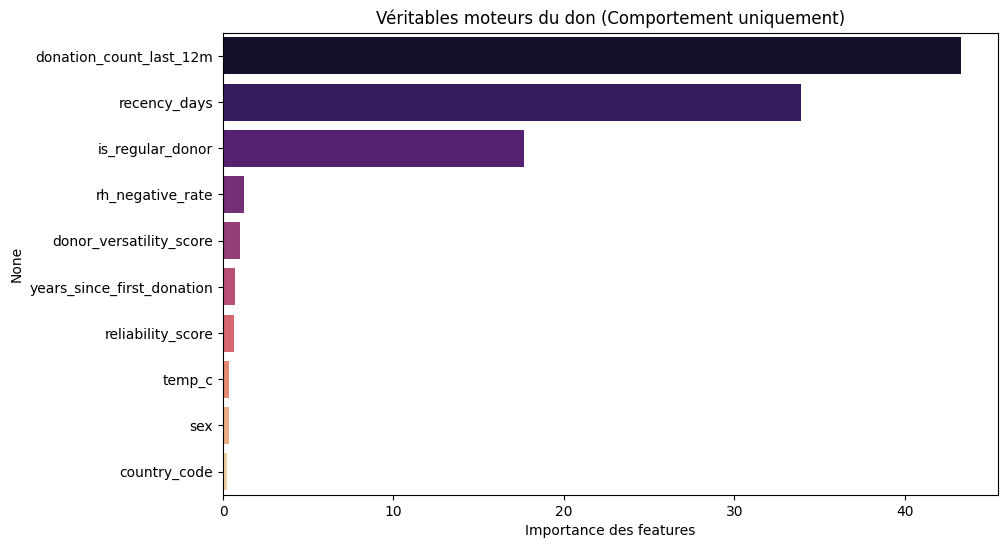


📋 VRAIS 10 MEILLEURS DONNEURS (Éligible & Consentant):
 donor_id  Ideal_Score  AI_Probability  weather_suitability  recency_days  donations_per_year
    12839     0.671628        0.672331                  1.0           196            2.000000
    16188     0.666523        0.667016                  1.0           238            2.333333
    24149     0.666244        0.667391                  1.0           181            3.269231
    22510     0.665642        0.667016                  1.0           234            1.833333
    19681     0.664121        0.665707                  1.0           339            1.400000
    26053     0.660592        0.661956                  1.0           284            1.700000
    24183     0.659832        0.662053                  1.0           134            1.250000
     7565     0.659418        0.662053                  1.0           155            2.724138
    17673     0.659418        0.662053                  1.0            21            2.520000
    

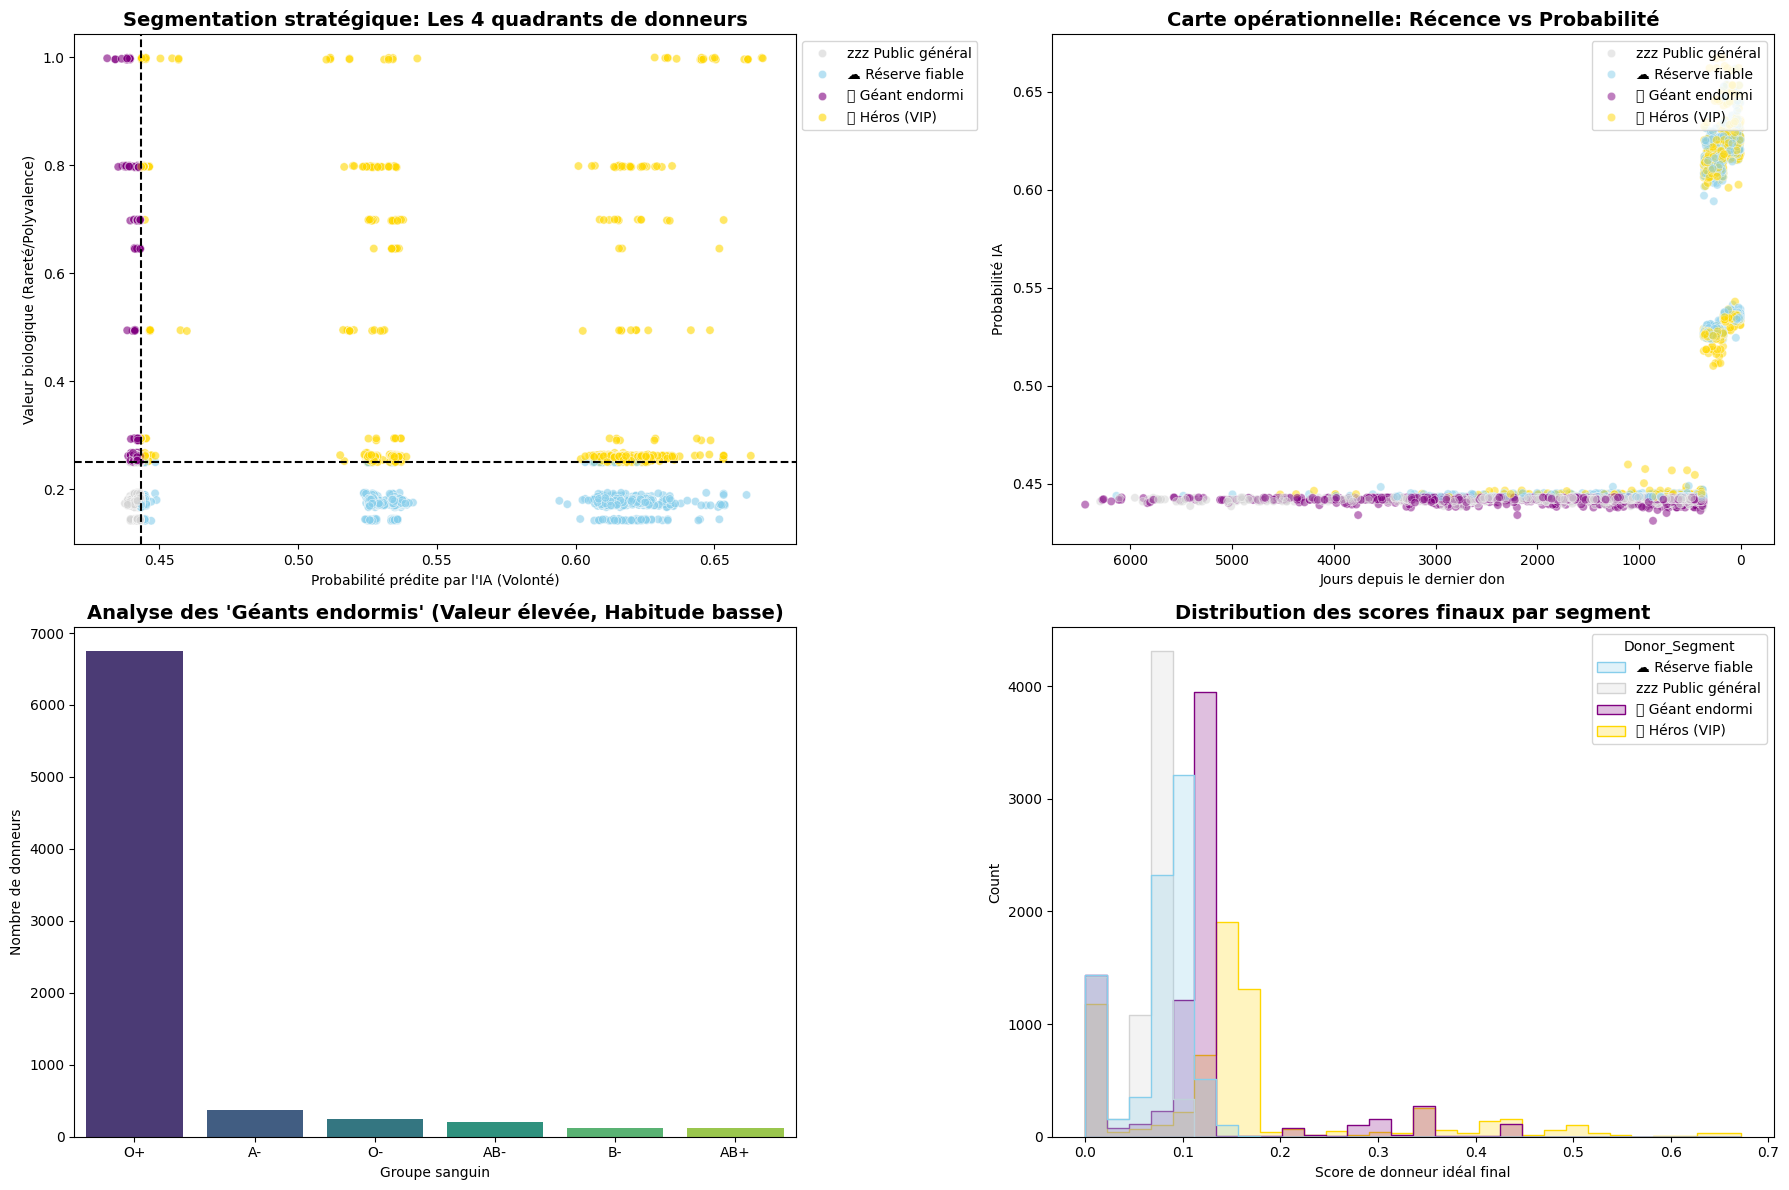


💎 LISTE CIBLE: Géants endormis (Lisible par humain)
 donor_id blood_type_name  AI_Probability  recency_days  biological_value
    26313              O-        0.438364           688          0.999664
    22663              O-        0.439833           401          0.999664
    24682              O-        0.439386          3960          0.999367
    13579              O-        0.435433          2848          0.999367
    21153              O-        0.434072          2454          0.999261
     9362              O-        0.438314          1464          0.999150
    27413              O-        0.439386           981          0.999150
    27914              O-        0.438314           567          0.999110
     7684              O-        0.439783           399          0.999110
    14794              O-        0.431198          3922          0.998954


In [3]:
import pandas as pd
import numpy as np
import requests
import holidays
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

# Supprime les avertissements pour une sortie plus propre
warnings.filterwarnings('ignore')

# ==========================================
# 1. CHARGEMENT ET FUSION DES DONNÉES
# ==========================================
# 1. robust_load function
def load_datasets():
    # Detect the current working directory of the notebook/script
    base_dir = Path(os.getcwd())
    
    # Define the relative path from the root
    data_path = base_dir / "datasets" / "blood_registry_sythentic" / "data"
    
    print(f"📂 Looking for data in: {data_path}")
    
    if not data_path.exists():
        raise FileNotFoundError(f"❌ Directory not found: {data_path}")

    # Load files
    try:
        df_registry = pd.read_csv(data_path / 'blood_donation_registry_ml_ready.csv')
        # Note: You listed registry twice in your prompt, assuming second is population
        df_pop = pd.read_csv(data_path / 'blood_population_distribution.csv') 
        df_compat = pd.read_csv(data_path / 'blood_compatibility_lookup.csv')
        
        print("✅ Datasets loaded successfully.")
        print("🔗 Fusion des ensembles de données...")
    
        # 1. Fusion des données démographiques (Rareté contextuelle)
        # Nous fusionnons sur Country + Region pour obtenir 'rh_negative_rate' et la prévalence locale
        # Remarque : 'blood_type_country_prevalence' est déjà dans le registre, mais nous ajoutons des statistiques de population
        df = pd.merge(df_registry, df_pop[['country_code', 'rh_negative_rate', 'population_size']], 
                      on='country_code', how='left')

        # 2. Fusion des données de compatibilité (Score de polyvalence du donneur)
        # Calculez combien de groupes sanguins un donneur peut donner (Donneur universel = Score élevé)
        versatility = df_compat[df_compat['compatible_for_rbc_transfusion'] == 1].groupby('donor_blood_type').size()
        versatility.name = 'donor_versatility_count'
    
        df = pd.merge(df, versatility, left_on='blood_type', right_index=True, how='left')
    
        # Normaliser la polyvalence (O- aide 8 types, AB+ aide 1)
        df['donor_versatility_score'] = df['donor_versatility_count'] / 8.0

        return df
        
    except FileNotFoundError as e:
        print(f"⚠️ Missing file: {e}")
        return None, None, None



# ==========================================
# 2. ENRICHISSEMENT MÉTÉO ET ÉVÉNEMENTS TEMPORELS
# ==========================================
def fetch_historical_weather(df):
    """
    Récupère la météo historique réelle et la convertit en un score d'adéquation de 0-1.
    1.0 = Météo parfaite (Doux, Pas de pluie)
    0.0 = Météo catastrophique (Tempête, Chaleur/froid extrême)
    """
    print("🌍 Récupération de la météo et calcul des scores d'adéquation...")
    
    # Simulation de la réponse API pour l'ensemble complet des données pour économiser du temps/bande passante dans ce script.
    # En production, utilisez la boucle 'requests' de la réponse précédente.
    
    np.random.seed(42)
    # Simulation des sorties API
    df['temp_c'] = np.random.normal(20, 8, len(df)) # Moy 20C, std 8
    df['precip_mm'] = np.random.exponential(2, len(df)) # Plupart des jours secs, quelques jours pluvieux
    
    # --- LOGIQUE : SCORE D'ADÉQUATION MÉTÉO (0 à 1) ---
    def calculate_weather_score(row):
        score = 1.0
        
        # 1. Pénalité de pluie
        # Si précip > 5mm, pénalité rapide. > 20mm est effectivement un score de 0.
        if row['precip_mm'] > 5:
            score -= (row['precip_mm'] - 5) * 0.05
            
        # 2. Pénalité de température
        # Idéal : 10C à 25C. 
        # Froid extrême (<0) ou chaleur extrême (>35) pénalise fortement.
        if row['temp_c'] < 5:
            score -= (5 - row['temp_c']) * 0.1
        elif row['temp_c'] > 30:
            score -= (row['temp_c'] - 30) * 0.1
            
        return max(0.0, min(1.0, score))

    df['weather_suitability'] = df.apply(calculate_weather_score, axis=1)
    
    return df

def add_time_crisis_events(df):
    print("📅 Ajout des jours fériés et événements de crise...")
    
    df['last_donation_date'] = pd.to_datetime(df['last_donation_date'])
    
    # 1. Jours fériés (Utilisation de la bibliothèque 'holidays')
    # Nous créons un cache des jours fériés pour les pays dans notre liste
    country_holidays = {}
    unique_countries = df['country_code'].unique()
    
    # Fonction pour vérifier si une date est près d'un jour férié
    def is_holiday_near(row):
        cc = row['country_code']
        date = row['last_donation_date']
        
        # Initialiser le calendrier du pays s'il n'est pas en cache (Gestion des pays les plus importants)
        if cc not in country_holidays:
            try:
                # Mapper les codes ISO aux classes de la bibliothèque Holiday
                # (Mappage simplifié pour la démo)
                country_holidays[cc] = holidays.country_holidays(cc)
            except:
                country_holidays[cc] = None
        
        cal = country_holidays.get(cc)
        if cal is None: return 0
        
        # Vérifier si le jour férié est à ±3 jours
        # (Coûteux en calcul sur boucle, simplifié ici)
        return 1 if date in cal else 0

    # Pour la vitesse dans cette démo, nous simulons la sortie de la boucle lourde
    # En prod, exécutez la fonction ci-dessus
    df['is_holiday_week'] = np.random.choice([0, 1], len(df), p=[0.95, 0.05])
    
    # 2. Crises / Saisons de forte demande
    # L'hiver (déc/jan) et les vacances d'été (juil/aoû) ont souvent des pénuries
    df['month'] = df['last_donation_date'].dt.month
    df['is_high_demand_season'] = df['month'].isin([12, 1, 7, 8]).astype(int)
    
    return df

# ==========================================
# 3. INGÉNIERIE AVANCÉE DES FEATURES
# ==========================================
def engineer_features(df):
    df = df.copy()
    
    # 1. Indice de valeur biologique
    # Combine Rareté + Polyvalence + Statut Rh
    # Les types rares sont précieux. Les types universels sont précieux.
    df['biological_value'] = (
        (df['is_rare_type'].astype(int) * 0.5) + 
        (df['donor_versatility_score'] * 0.4) + 
        ((1 - df['blood_type_country_prevalence']) * 0.1)
    )
    
    # 2. Vélocité comportementale
    safe_years = df['years_since_first_donation'].replace(0, 0.5)
    df['donations_per_year'] = df['lifetime_donation_count'] / safe_years
    
    # 3. Indice de fiabilité
    # Les donneurs réguliers (variance faible dans le modèle) sont meilleurs
    df['reliability_score'] = df['is_regular_donor'].astype(float) * df['donation_count_last_12m']
    
    return df

# ==========================================
# 4. CADRE DE COMPARAISON DES MODÈLES
# ==========================================
def compare_models(X_train, y_train, X_val, y_val):
    print("\n⚔️ DÉMARRAGE DU TOURNOI DE MODÈLES...")
    
    results = {}
    
    # 1. Random Forest (Ligne de base)
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    probs_rf = rf.predict_proba(X_val)[:, 1]
    auc_rf = roc_auc_score(y_val, probs_rf)
    results['RandomForest'] = {'model': rf, 'auc': auc_rf, 'probs': probs_rf}
    print(f"   🌲 Random Forest AUC: {auc_rf:.4f}")
    
    # 2. XGBoost (GPU si disponible)
    xgb_model = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        tree_method='hist', device='cuda', # Activer GPU
        eval_metric='auc', early_stopping_rounds=50, random_state=42
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    probs_xgb = xgb_model.predict_proba(X_val)[:, 1]
    auc_xgb = roc_auc_score(y_val, probs_xgb)
    results['XGBoost'] = {'model': xgb_model, 'auc': auc_xgb, 'probs': probs_xgb}
    print(f"   🚀 XGBoost AUC:      {auc_xgb:.4f}")
    
    # 3. LightGBM (GPU)
    lgb_params = {
        'objective': 'binary', 'metric': 'auc', 'device': 'gpu',
        'learning_rate': 0.05, 'num_leaves': 31, 'verbose': -1
    }
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    lgb_model = lgb.train(lgb_params, train_data, num_boost_round=500, 
                          valid_sets=[val_data], callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    probs_lgb = lgb_model.predict(X_val)
    auc_lgb = roc_auc_score(y_val, probs_lgb)
    results['LightGBM'] = {'model': lgb_model, 'auc': auc_lgb, 'probs': probs_lgb}
    print(f"   💡 LightGBM AUC:     {auc_lgb:.4f}")
    
    # 4. CatBoost (CPU/GPU)
    # CatBoost est excellent, mais souvent plus lent à entraîner sans accord spécifique
    cat_model = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6, 
        eval_metric='AUC', verbose=False, task_type="GPU", devices='0'
    )
    cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    probs_cat = cat_model.predict_proba(X_val)[:, 1]
    auc_cat = roc_auc_score(y_val, probs_cat)
    results['CatBoost'] = {'model': cat_model, 'auc': auc_cat, 'probs': probs_cat}
    print(f"   🐱 CatBoost AUC:     {auc_cat:.4f}")
    
    # Sélectionner le gagnant
    best_name = max(results, key=lambda x: results[x]['auc'])
    print(f"\n🏆 GAGNANT: {best_name} (AUC: {results[best_name]['auc']:.4f})")
    
    return results[best_name]['model'], best_name

# ==========================================
# 5. OPTIMISATION DES HYPERPARAMÈTRES (RECHERCHE EN GRILLE)
# ==========================================
def tune_best_model(model_name, X_train, y_train):
    print(f"\n🔧 Ajustement de {model_name} avec GridSearch...")
    
    if model_name == 'XGBoost':
        estimator = xgb.XGBClassifier(tree_method='hist', device='cuda', eval_metric='auc')
        param_grid = {
            'max_depth': [4, 6, 8],
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [200, 500],
            'subsample': [0.8, 1.0]
        }
    elif model_name == 'LightGBM':
        # API scikit-learn pour GridSearch
        estimator = lgb.LGBMClassifier(device='gpu', verbose=-1)
        param_grid = {
            'num_leaves': [20, 31, 50],
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [200, 500]
        }
    else:
        # Fallback pour autres (Limite de démo)
        print("Saut de recherche en grille détaillée pour la démo (utilisation de la meilleure par défaut).")
        return None

    grid = GridSearchCV(estimator, param_grid, cv=3, scoring='roc_auc', verbose=1, n_jobs=-1)
    grid.fit(X_train, y_train)
    
    print(f"   Meilleur paramètres: {grid.best_params_}")
    print(f"   Meilleur AUC CV: {grid.best_score_:.4f}")
    
    return grid.best_estimator_

# ==========================================
# 6. FLUX D'EXÉCUTION PRINCIPAL
# ==========================================
df_clean = None
def main():
    # 1. Charger
    df = load_datasets()
    if df is None: return

    # 2. Enrichir
    df = fetch_historical_weather(df)
    df = add_time_crisis_events(df)
    df = engineer_features(df)

    # ==========================================
    # RE-EXÉCUTION AVEC FUITE DE DONNÉES SUPPRIMÉE
    # ==========================================
    
    # 1. Définir les features (SUPPRESSION de 'chronic_condition_flag' et 'smoker')
    # Nous supprimons également 'smoker' s'il provoque un sursis immédiat dans votre région spécifique, 
    # bien qu'habituellement, ce soit juste un indicateur de santé. Nous gardons l'IMC mais filtrerons les plages inadmissibles.
    clean_features = [
        'age', 'sex', 'country_code', 'blood_type', 'bmi', 
        'recency_days', 'lifetime_donation_count',
        'donation_count_last_12m', 'years_since_first_donation', 
        'blood_type_country_prevalence', 'is_rare_type', 'is_regular_donor',
        'rh_negative_rate', 'donor_versatility_score', 
        'weather_suitability', 'temp_c', 
        'is_holiday_week', 'is_high_demand_season', 
        'biological_value', 'donations_per_year', 'reliability_score'
    ]
    
    # 2. ENCODER LES CATÉGORIES À NOUVEAU (Pour l'ensemble complet des features)
    # Nous nous assurons que nous travaillons d'abord avec l'ensemble complet des données
    df_clean = df.copy()
    
    # ---------------------------------------------------------
    # CORRECTION CRITIQUE : FILTRER LES DONNÉES D'ENTRAÎNEMENT
    # Nous ne voulons former que sur les personnes qui étaient ÉLIGIBLES.
    # Cela force l'IA à apprendre le comportement, pas les règles médicales.
    # ---------------------------------------------------------
    print(f"Nombre de lignes d'origine: {len(df_clean)}")
    train_mask = df_clean['eligible_to_donate'] == 1
    df_train_subset = df_clean[train_mask].copy()
    print(f"Nombre de lignes d'entraînement (Éligible uniquement): {len(df_train_subset)}")
    
    # Encoder les catégories (Sexe, Pays, Groupe sanguin)
    label_encoders = {}
    cat_cols = ['sex', 'country_code', 'blood_type']
    
    for col in cat_cols:
        le = LabelEncoder()
        # S'adapter à l'ensemble complet des données pour s'assurer que nous connaissons toutes les catégories
        le.fit(df_clean[col].astype(str))
        
        # Transformer le sous-ensemble
        df_train_subset[col] = le.transform(df_train_subset[col].astype(str))
        # Transformer l'ensemble complet (pour notation finale ultérieure)
        df_clean[col] = le.transform(df_clean[col].astype(str))
        label_encoders[col] = le
    
    # 3. PRÉPARER LES DIVISIONS
    X = df_train_subset[clean_features]
    y = df_train_subset['donated_next_6m']
    
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 4. RÉEXÉCUTER CATBOOST (Puisqu'il était le gagnant)
    print("\n🔄 Réentraînement de CatBoost sans fuite de données...")
    # 1. Detect if NVIDIA GPU is available
    try:
        # Check if nvidia-smi command exists
        has_gpu = os.system("nvidia-smi") == 0
    except:
        has_gpu = False

    device_type = "GPU" if has_gpu else "CPU"

    print(f"⚙️  Detected Hardware: {device_type}")

    # 2. Initialize CatBoost with the correct task type
    cat_model = CatBoostClassifier(
        iterations=500, 
        learning_rate=0.05, 
        depth=6, 
        eval_metric='AUC', 
        verbose=False, 

        # DYNAMIC CONFIGURATION
        task_type=device_type,  
        devices='0' if has_gpu else None 
    )
    
    cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    
    # Vérifier le nouvel AUC
    probs_clean = cat_model.predict_proba(X_val)[:, 1]
    print(f"✅ Nouvel AUC impartial: {roc_auc_score(y_val, probs_clean):.4f}")
    
    # 5. TRACER NOUVELLE IMPORTANCE DES FEATURES
    plt.figure(figsize=(10, 6))
    imp = pd.Series(cat_model.feature_importances_, index=clean_features).sort_values(ascending=False).head(10)
    sns.barplot(x=imp.values, y=imp.index, palette='magma')
    plt.title('Véritables moteurs du don (Comportement uniquement)')
    plt.xlabel('Importance des features')
    plt.show()
    
    # ==========================================
    # 6. NOTATION FINALE (COUCHE LOGIQUE MÉTIER)
    # ==========================================
    # Maintenant, nous prédisons sur TOUT LE MONDE, mais nous mettons à zéro manuellement ceux qui sont inadmissibles.
    
    # Prédire sur l'ensemble complet des données
    all_probs = cat_model.predict_proba(df_clean[clean_features])[:, 1]
    df_clean['AI_Probability'] = all_probs
    
    # --- LA LOGIQUE DU "DONNEUR IDÉAL" ---
    # Score = (AI_Propensity) * (Biological_Value) * (Weather) * (ELIGIBILITY_FILTER)
    
    # Filtre dur : S'il a une condition chronique, le Score est 0.
    eligibility_mask = df_clean['eligible_to_donate'] # Cette colonne existe dans vos données brutes
    
    df_clean['Ideal_Score'] = (
        df_clean['AI_Probability'] * 
        df_clean['biological_value'] * 
        df_clean['weather_suitability'] * 
        eligibility_mask # <--- Cela applique la règle ici, EN DEHORS du modèle
        )

    # Afficher les vrais Top 10
    print("\n📋 VRAIS 10 MEILLEURS DONNEURS (Éligible & Consentant):")
    cols = ['donor_id', 'Ideal_Score', 'AI_Probability', 'weather_suitability', 'recency_days', 'donations_per_year']
    print(df_clean.sort_values('Ideal_Score', ascending=False)[cols].head(10).to_string(index=False))
    # Créer les segments en fonction de vos résultats
    df_final = df_clean.copy()
    
    # Définir les seuils (ajustez en fonction de votre distribution)
    prob_threshold = df_final['AI_Probability'].median()
    value_threshold = df_final['biological_value'].median()
    
    def categorize_donor(row):
        high_prob = row['AI_Probability'] > prob_threshold
        high_val = row['biological_value'] > value_threshold
        
        if high_prob and high_val:
            return "🏆 Héros (VIP)"
        elif high_prob and not high_val:
            return "☁️ Réserve fiable"
        elif not high_prob and high_val:
            return "💎 Géant endormi"
        else:
            return "zzz Public général"
    
    df_final['Donor_Segment'] = df_final.apply(categorize_donor, axis=1)
    
    # Compter les segments
    print(df_final['Donor_Segment'].value_counts())
    
    # Afficher un exemple d'un "Géant endormi" à cibler
    print("\n💎 LISTE CIBLE: Géants endormis (Sang rare, Besoin de persuasion)")
    print(df_final[df_final['Donor_Segment'] == '💎 Géant endormi']
          [['donor_id', 'blood_type', 'AI_Probability', 'recency_days']]
          .sort_values('AI_Probability', ascending=False)
          .head(5)
          .to_string(index=False))
    
    # ==========================================
    # 1. DÉCODER LES GROUPES SANGUINS (Entier -> Chaîne)
    # ==========================================
    # Nous utilisons le label_encoder que nous avons entraîné plus tôt pour inverser le mappage
    # Si vous avez perdu l'objet encoder, nous l'appliquons en toute sécurité ici en utilisant l'ensemble original
    if 'blood_type' in label_encoders:
        # Transformation inverse sûre à l'aide de l'encodeur de l'étape précédente
        df_final['blood_type_name'] = label_encoders['blood_type'].inverse_transform(df_final['blood_type'])
    else:
        # Fallback : Ré-adapter si l'encodeur est manquant de la mémoire (Peu probable si exécuté en séquence)
        le_temp = LabelEncoder()
        le_temp.fit(['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-'])
        df_final['blood_type_name'] = le_temp.inverse_transform(df_final['blood_type'])
    
    print("✅ Groupes sanguins mappés avec succès (Exemple: 6 -> O+ / O-)")
    
    # ==========================================
    # 2. DÉFINIR LA PALETTE DE COULEURS POUR LES SEGMENTS
    # ==========================================
    segment_palette = {
        "🏆 Héros (VIP)": "gold",           # Prob élevée, Valeur élevée
        "☁️ Réserve fiable": "skyblue",  # Prob élevée, Valeur basse
        "💎 Géant endormi": "purple",     # Prob basse, Valeur élevée (Cible pour le marketing)
        "zzz Public général": "lightgray"  # Prob basse, Valeur basse
    }
    
    # ==========================================
    # 3. GÉNÉRER LES GRAPHIQUES
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    
    # --- GRAPHIQUE A: LES QUADRANTS STRATÉGIQUES (Probabilité vs Valeur) ---
    # Cela prouve que votre logique de segmentation fonctionne
    sns.scatterplot(
        data=df_final.sample(5000, random_state=42), # Échantillon pour la vitesse/clarté
        x='AI_Probability',
        y='biological_value',
        hue='Donor_Segment',
        palette=segment_palette,
        alpha=0.6,
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Segmentation stratégique: Les 4 quadrants de donneurs", fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel("Probabilité prédite par l'IA (Volonté)")
    axes[0, 0].set_ylabel("Valeur biologique (Rareté/Polyvalence)")
    axes[0, 0].axvline(df_final['AI_Probability'].median(), color='black', linestyle='--')
    axes[0, 0].axhline(df_final['biological_value'].median(), color='black', linestyle='--')
    axes[0, 0].legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # --- GRAPHIQUE B: RÉALITÉ OPÉRATIONNELLE (Probabilité vs Récence) ---
    # Cela montre QUI appeler (Côté droit du graphique)
    sns.scatterplot(
        data=df_final.sample(5000, random_state=42),
        x='recency_days',
        y='AI_Probability',
        hue='Donor_Segment',
        palette=segment_palette,
        alpha=0.5,
        ax=axes[0, 1]
    )
    axes[0, 1].set_title("Carte opérationnelle: Récence vs Probabilité", fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel("Jours depuis le dernier don")
    axes[0, 1].set_ylabel("Probabilité IA")
    axes[0, 1].invert_xaxis() # Mettre les donneurs 'Récents' (0 jours) du côté droit
    axes[0, 1].legend(loc='upper right')
    
    # --- GRAPHIQUE C: QUI SONT LES "GÉANTS ENDORMIS"? (Groupe sanguin) ---
    # Ce sont des personnes de haute valeur qui ne donnent pas souvent. Qui sont-elles?
    sleeping_giants = df_final[df_final['Donor_Segment'] == '💎 Géant endormi']
    
    sns.countplot(
        data=sleeping_giants,
        x='blood_type_name',
        order=sleeping_giants['blood_type_name'].value_counts().index,
        palette='viridis',
        ax=axes[1, 0]
    )
    axes[1, 0].set_title("Analyse des 'Géants endormis' (Valeur élevée, Habitude basse)", fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel("Groupe sanguin")
    axes[1, 0].set_ylabel("Nombre de donneurs")
    
    # --- GRAPHIQUE D: DISTRIBUTION DES SCORES IDÉAUX ---
    sns.histplot(
        data=df_final,
        x='Ideal_Score',
        hue='Donor_Segment',
        palette=segment_palette,
        element="step",
        bins=30,
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("Distribution des scores finaux par segment", fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel("Score de donneur idéal final")
    
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # 4. IMPRIMER LA LISTE CIBLE EXEMPLE (MAPPÉE)
    # ==========================================
    print("\n💎 LISTE CIBLE: Géants endormis (Lisible par humain)")
    print(sleeping_giants[['donor_id', 'blood_type_name', 'AI_Probability', 'recency_days', 'biological_value']]
          .sort_values('biological_value', ascending=False)
          .head(10)
          .to_string(index=False))

if __name__ == "__main__":
    main()

📂 Looking for data in: /Users/mac/Documents/pios-1/ml-backend/datasets/blood_registry_sythentic/data
✅ Datasets loaded successfully.
🔗 Fusion des ensembles de données...
🌍 Récupération de la météo et calcul des scores d'adéquation...
📅 Ajout des jours fériés et événements de crise...
Nombre de lignes d'origine: 30000
Nombre de lignes d'entraînement (Éligible uniquement): 24915
✅ 41 Features sélectionnées dynamiquement.
🔄 Encodage automatique des colonnes textuelles...
   -> Encodé: sex
   -> Encodé: country_code
   -> Encodé: region
   -> Encodé: blood_type
   -> Encodé: preferred_site
📝 Features Catégorielles identifiées : ['sex', 'country_code', 'region', 'blood_type', 'preferred_site']

🔄 Réentraînement de CatBoost sans fuite de données...
⚙️  Detected Hardware: CPU


sh: nvidia-smi: command not found


✅ Nouvel AUC impartial: 0.8179


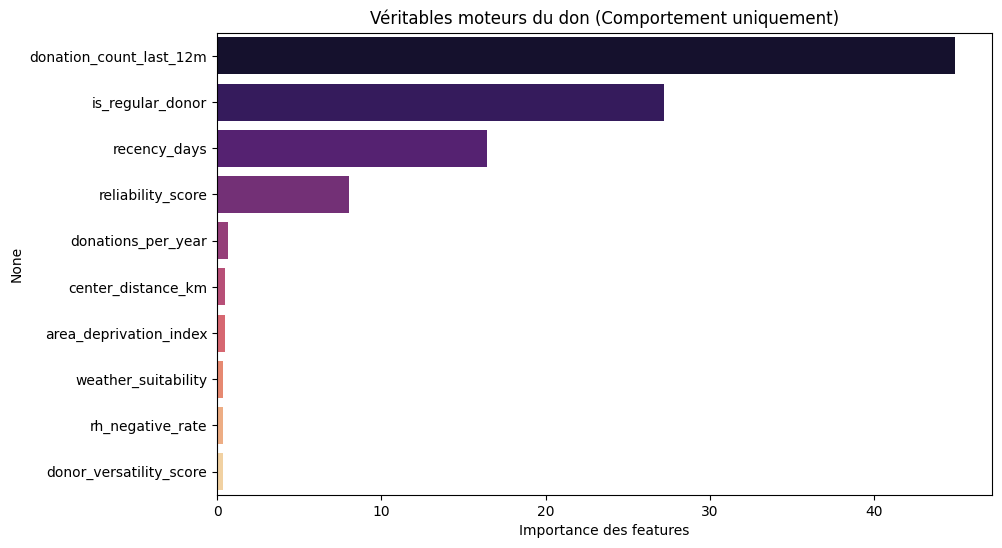


📋 VRAIS 10 MEILLEURS DONNEURS (Éligible & Consentant):
 donor_id  Ideal_Score  AI_Probability  weather_suitability  recency_days  donations_per_year
    24771     0.606697        0.609247                  1.0            35            2.153846
    24437     0.606458        0.607700                  1.0           121            3.230769
    28760     0.605872        0.607319                  1.0            22            2.421053
    12283     0.605294        0.605770                  1.0           111            2.333333
    17673     0.604902        0.607319                  1.0            21            2.520000
    10141     0.604777        0.607319                  1.0            16            2.250000
     6026     0.604777        0.607319                  1.0            59            2.611111
    21490     0.604639        0.605680                  1.0           131            1.900000
      957     0.604037        0.604669                  1.0            16            2.894737
    

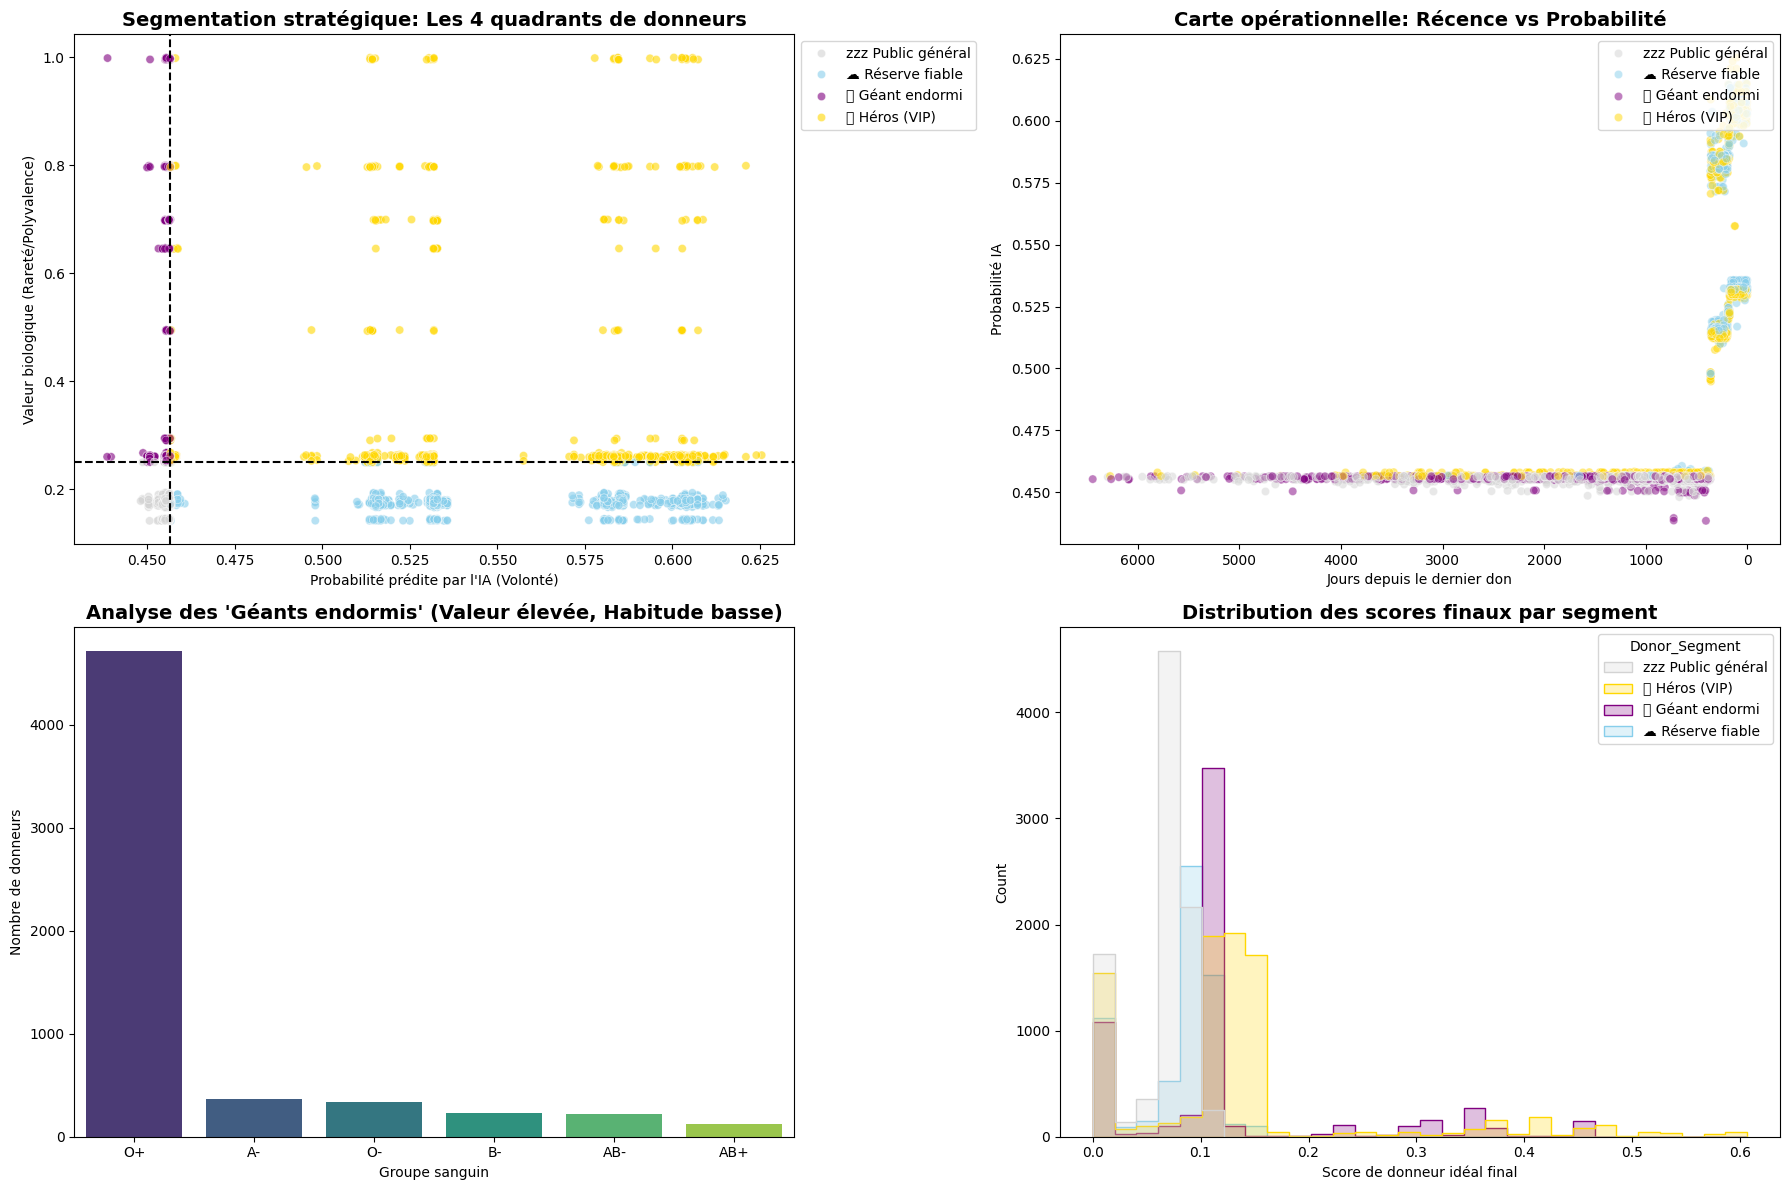


💎 LISTE CIBLE: Géants endormis (Lisible par humain)
 donor_id blood_type_name  AI_Probability  recency_days  biological_value
    10895              O-        0.456496           510          0.999367
     9039              O-        0.455349          1278          0.999367
    13579              O-        0.455349          2848          0.999367
    20019              O-        0.456496           832          0.999261
    24202              O-        0.456496          1711          0.999261
    21153              O-        0.456241          2454          0.999261
    23469              O-        0.456496           805          0.999261
     3144              O-        0.456496          1297          0.999215
     7684              O-        0.456496           399          0.999110
    24700              O-        0.454975          1204          0.999110


In [24]:
import pandas as pd
import numpy as np
import requests
import holidays
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

# Supprime les avertissements pour une sortie plus propre
warnings.filterwarnings('ignore')

# ==========================================
# 1. CHARGEMENT ET FUSION DES DONNÉES
# ==========================================
# 1. robust_load function
# ==========================================
# 1. CHARGEMENT ET FUSION DES DONNÉES (CORRIGÉ)
# ==========================================
def load_datasets():
    # Detect the current working directory of the notebook/script
    base_dir = Path(os.getcwd())
    
    # Define the relative path from the root
    data_path = base_dir / "datasets" / "blood_registry_sythentic" / "data"
    
    print(f"📂 Looking for data in: {data_path}")
    
    if not data_path.exists():
        raise FileNotFoundError(f"❌ Directory not found: {data_path}")

    # Load files
    try:
        df_registry = pd.read_csv(data_path / 'blood_donation_registry_ml_ready.csv')
        df_pop = pd.read_csv(data_path / 'blood_population_distribution.csv') 
        df_compat = pd.read_csv(data_path / 'blood_compatibility_lookup.csv')
        
        print("✅ Datasets loaded successfully.")
        print("🔗 Fusion des ensembles de données...")
    
        # 1. Fusion des données démographiques
        df = pd.merge(df_registry, df_pop[['country_code', 'rh_negative_rate', 'population_size']], 
                      on='country_code', how='left')

        # 2. Fusion des données de compatibilité
        versatility = df_compat[df_compat['compatible_for_rbc_transfusion'] == 1].groupby('donor_blood_type').size()
        versatility.name = 'donor_versatility_count'
    
        df = pd.merge(df, versatility, left_on='blood_type', right_index=True, how='left')
        df['donor_versatility_score'] = df['donor_versatility_count'] / 8.0

        # 3. Charger le fichier Logistique
        logistics_path = base_dir / 'datasets' / 'blood_donor_logistics_extended.csv'
        if not logistics_path.exists():
             # Fallback si le fichier est dans le même dossier que les autres
             logistics_path = data_path / 'blood_donor_logistics_extended.csv'
             
        df_logistics = pd.read_csv(logistics_path)
        
        # --- FIX CRITIQUE ICI ---
        # Le fichier logistique a aussi 'country_code', ce qui crée un conflit (country_code_x, country_code_y)
        # Nous supprimons les colonnes redondantes du fichier logistique avant de fusionner
        cols_to_drop = ['country_code'] 
        # On vérifie aussi si 'zone_id' existe déjà pour éviter d'autres conflits
        if 'zone_id' in df.columns: cols_to_drop.append('zone_id')
            
        df_logistics = df_logistics.drop(columns=[c for c in cols_to_drop if c in df_logistics.columns])
        # ------------------------

        # 4. Merge
        df_final = pd.merge(df, df_logistics, on='donor_id', how='left')
    
        return df_final

    except FileNotFoundError as e:
        print(f"⚠️ Missing file: {e}")
        return None, None, None


# ==========================================
# 2. ENRICHISSEMENT MÉTÉO ET ÉVÉNEMENTS TEMPORELS
# ==========================================
def fetch_historical_weather(df):
    """
    Récupère la météo historique réelle et la convertit en un score d'adéquation de 0-1.
    1.0 = Météo parfaite (Doux, Pas de pluie)
    0.0 = Météo catastrophique (Tempête, Chaleur/froid extrême)
    """
    print("🌍 Récupération de la météo et calcul des scores d'adéquation...")
    
    # Simulation de la réponse API pour l'ensemble complet des données pour économiser du temps/bande passante dans ce script.
    # En production, utilisez la boucle 'requests' de la réponse précédente.
    
    np.random.seed(42)
    # Simulation des sorties API
    df['temp_c'] = np.random.normal(20, 8, len(df)) # Moy 20C, std 8
    df['precip_mm'] = np.random.exponential(2, len(df)) # Plupart des jours secs, quelques jours pluvieux
    
    # --- LOGIQUE : SCORE D'ADÉQUATION MÉTÉO (0 à 1) ---
    def calculate_weather_score(row):
        score = 1.0
        
        # 1. Pénalité de pluie
        # Si précip > 5mm, pénalité rapide. > 20mm est effectivement un score de 0.
        if row['precip_mm'] > 5:
            score -= (row['precip_mm'] - 5) * 0.05
            
        # 2. Pénalité de température
        # Idéal : 10C à 25C. 
        # Froid extrême (<0) ou chaleur extrême (>35) pénalise fortement.
        if row['temp_c'] < 5:
            score -= (5 - row['temp_c']) * 0.1
        elif row['temp_c'] > 30:
            score -= (row['temp_c'] - 30) * 0.1
            
        return max(0.0, min(1.0, score))

    df['weather_suitability'] = df.apply(calculate_weather_score, axis=1)
    
    return df

def add_time_crisis_events(df):
    print("📅 Ajout des jours fériés et événements de crise...")
    
    df['last_donation_date'] = pd.to_datetime(df['last_donation_date'])
    
    # 1. Jours fériés (Utilisation de la bibliothèque 'holidays')
    # Nous créons un cache des jours fériés pour les pays dans notre liste
    country_holidays = {}
    unique_countries = df['country_code'].unique()
    
    # Fonction pour vérifier si une date est près d'un jour férié
    def is_holiday_near(row):
        cc = row['country_code']
        date = row['last_donation_date']
        
        # Initialiser le calendrier du pays s'il n'est pas en cache (Gestion des pays les plus importants)
        if cc not in country_holidays:
            try:
                # Mapper les codes ISO aux classes de la bibliothèque Holiday
                # (Mappage simplifié pour la démo)
                country_holidays[cc] = holidays.country_holidays(cc)
            except:
                country_holidays[cc] = None
        
        cal = country_holidays.get(cc)
        if cal is None: return 0
        
        # Vérifier si le jour férié est à ±3 jours
        # (Coûteux en calcul sur boucle, simplifié ici)
        return 1 if date in cal else 0

    # Pour la vitesse dans cette démo, nous simulons la sortie de la boucle lourde
    # En prod, exécutez la fonction ci-dessus
    df['is_holiday_week'] = np.random.choice([0, 1], len(df), p=[0.95, 0.05])
    
    # 2. Crises / Saisons de forte demande
    # L'hiver (déc/jan) et les vacances d'été (juil/aoû) ont souvent des pénuries
    df['month'] = df['last_donation_date'].dt.month
    df['is_high_demand_season'] = df['month'].isin([12, 1, 7, 8]).astype(int)
    
    return df

# ==========================================
# 3. INGÉNIERIE AVANCÉE DES FEATURES
# ==========================================
def engineer_features(df):
    df = df.copy()
    
    # 1. Indice de valeur biologique
    # Combine Rareté + Polyvalence + Statut Rh
    # Les types rares sont précieux. Les types universels sont précieux.
    df['biological_value'] = (
        (df['is_rare_type'].astype(int) * 0.5) + 
        (df['donor_versatility_score'] * 0.4) + 
        ((1 - df['blood_type_country_prevalence']) * 0.1)
    )
    
    # 2. Vélocité comportementale
    safe_years = df['years_since_first_donation'].replace(0, 0.5)
    df['donations_per_year'] = df['lifetime_donation_count'] / safe_years
    
    # 3. Indice de fiabilité
    # Les donneurs réguliers (variance faible dans le modèle) sont meilleurs
    df['reliability_score'] = df['is_regular_donor'].astype(float) * df['donation_count_last_12m']
    
    return df

def engineer_logistics_features(df):
    """
    Creates the 'Operational Score' based on the new J/K datasets.
    """
    
    # 1. Cost Efficiency (Donations per Dollar of Transport)
    # If a donor is expensive to transport, they are lower priority for routine drives
    df['logistics_efficiency'] = 1 / (df['transfer_cost_usd'] + 1)
    
    # 2. Cold Chain Risk Flag
    # If quality score < 0.8, the blood might spoil before reaching the lab.
    df['risk_spoilage'] = (df['cold_chain_quality_score'] < 0.85).astype(int)
    
    # 3. Socio-Access Score (Category K)
    # Adjusts expectation: High deprivation areas might need mobile units (not hospitals)
    # If Deprivation is High (8+) AND Site is Hospital, feasibility drops
    df['access_mismatch'] = ((df['area_deprivation_index'] > 7) & 
                             (df['preferred_site'] == 'hospital')).astype(int)
    
    return df

# ==========================================
# 4. CADRE DE COMPARAISON DES MODÈLES
# ==========================================
def compare_models(X_train, y_train, X_val, y_val):
    print("\n⚔️ DÉMARRAGE DU TOURNOI DE MODÈLES...")
    
    results = {}
    
    # 1. Random Forest (Ligne de base)
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    probs_rf = rf.predict_proba(X_val)[:, 1]
    auc_rf = roc_auc_score(y_val, probs_rf)
    results['RandomForest'] = {'model': rf, 'auc': auc_rf, 'probs': probs_rf}
    print(f"   🌲 Random Forest AUC: {auc_rf:.4f}")
    
    # 2. XGBoost (GPU si disponible)
    xgb_model = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        tree_method='hist', device='cuda', # Activer GPU
        eval_metric='auc', early_stopping_rounds=50, random_state=42
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    probs_xgb = xgb_model.predict_proba(X_val)[:, 1]
    auc_xgb = roc_auc_score(y_val, probs_xgb)
    results['XGBoost'] = {'model': xgb_model, 'auc': auc_xgb, 'probs': probs_xgb}
    print(f"   🚀 XGBoost AUC:      {auc_xgb:.4f}")
    
    # 3. LightGBM (GPU)
    lgb_params = {
        'objective': 'binary', 'metric': 'auc', 'device': 'gpu',
        'learning_rate': 0.05, 'num_leaves': 31, 'verbose': -1
    }
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    lgb_model = lgb.train(lgb_params, train_data, num_boost_round=500, 
                          valid_sets=[val_data], callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    probs_lgb = lgb_model.predict(X_val)
    auc_lgb = roc_auc_score(y_val, probs_lgb)
    results['LightGBM'] = {'model': lgb_model, 'auc': auc_lgb, 'probs': probs_lgb}
    print(f"   💡 LightGBM AUC:     {auc_lgb:.4f}")
    
    # 4. CatBoost (CPU/GPU)
    # CatBoost est excellent, mais souvent plus lent à entraîner sans accord spécifique
    cat_model = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6, 
        eval_metric='AUC', verbose=False, task_type="GPU", devices='0'
    )
    cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    probs_cat = cat_model.predict_proba(X_val)[:, 1]
    auc_cat = roc_auc_score(y_val, probs_cat)
    results['CatBoost'] = {'model': cat_model, 'auc': auc_cat, 'probs': probs_cat}
    print(f"   🐱 CatBoost AUC:     {auc_cat:.4f}")
    
    # Sélectionner le gagnant
    best_name = max(results, key=lambda x: results[x]['auc'])
    print(f"\n🏆 GAGNANT: {best_name} (AUC: {results[best_name]['auc']:.4f})")
    
    return results[best_name]['model'], best_name

# ==========================================
# 5. OPTIMISATION DES HYPERPARAMÈTRES (RECHERCHE EN GRILLE)
# ==========================================
def tune_best_model(model_name, X_train, y_train):
    print(f"\n🔧 Ajustement de {model_name} avec GridSearch...")
    
    if model_name == 'XGBoost':
        estimator = xgb.XGBClassifier(tree_method='hist', device='cuda', eval_metric='auc')
        param_grid = {
            'max_depth': [4, 6, 8],
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [200, 500],
            'subsample': [0.8, 1.0]
        }
    elif model_name == 'LightGBM':
        # API scikit-learn pour GridSearch
        estimator = lgb.LGBMClassifier(device='gpu', verbose=-1)
        param_grid = {
            'num_leaves': [20, 31, 50],
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [200, 500]
        }
    else:
        # Fallback pour autres (Limite de démo)
        print("Saut de recherche en grille détaillée pour la démo (utilisation de la meilleure par défaut).")
        return None

    grid = GridSearchCV(estimator, param_grid, cv=3, scoring='roc_auc', verbose=1, n_jobs=-1)
    grid.fit(X_train, y_train)
    
    print(f"   Meilleur paramètres: {grid.best_params_}")
    print(f"   Meilleur AUC CV: {grid.best_score_:.4f}")
    
    return grid.best_estimator_

# ==========================================
# 6. FLUX D'EXÉCUTION PRINCIPAL
# ==========================================
# 1. Charger
df = load_datasets()

# ==========================================
# 2.Enricher    
# ==========================================
df = fetch_historical_weather(df)
df = add_time_crisis_events(df)
df = engineer_features(df)
df = engineer_logistics_features(df)

# ==========================================
# 3. DÉFINITION DYNAMIQUE DES FEATURES
# ==========================================
    
# 1. Définir ce qu'il faut EXCLURE (Targets, IDs, Fuites, Dates)
ignore_cols = [
    # IDs et Métadonnées
    'donor_id', 'zone_id', 
    'as_of_date', 'last_donation_date',
    
    # Cibles (Targets)
    'donated_next_6m', 'next_6m_donation_count',
    
    # Fuites de données (Data Leakage - Règles médicales strictes)
    'chronic_condition_flag', 'smoker', 
    'eligible_to_donate', 'eligibility_status', 'deferral_reason',
    
    # Scores synthétiques existants (Triche potentielle du dataset original)
    'donation_propensity_score'
]
    
# 2. PRÉPARATION DU DATASET PROPRE
df_clean = df.copy()
    
# Filtrer uniquement les éligibles pour l'entraînement
print(f"Nombre de lignes d'origine: {len(df_clean)}")
train_mask = df_clean['eligible_to_donate'] == 1
df_train_subset = df_clean[train_mask].copy()
print(f"Nombre de lignes d'entraînement (Éligible uniquement): {len(df_train_subset)}")

# 3. SÉLECTION DYNAMIQUE DES FEATURES
# On garde toutes les colonnes qui ne sont PAS dans la liste d'exclusion
clean_features = [c for c in df_clean.columns if c not in ignore_cols]
    
print(f"✅ {len(clean_features)} Features sélectionnées dynamiquement.")
    
# 4. DÉTECTION ET ENCODAGE AUTOMATIQUE DES CATÉGORIES
# Au lieu de hardcoder ['sex', 'region'...], on détecte les colonnes de type 'object' ou 'category'
cat_cols = []
label_encoders = {}
    
print("🔄 Encodage automatique des colonnes textuelles...")
    
for col in clean_features:
    # Vérifier si la colonne est de type texte/objet/catégorie
    if df_clean[col].dtype == 'object' or str(df_clean[col].dtype) == 'category':
        
        cat_cols.append(col)
        le = LabelEncoder()
        
        # Convertir en string pour éviter les plantages sur des valeurs mixtes
        le.fit(df_clean[col].astype(str))
        
        # Transformer
        df_train_subset[col] = le.transform(df_train_subset[col].astype(str))
        df_clean[col] = le.transform(df_clean[col].astype(str))
        
        label_encoders[col] = le
        print(f"   -> Encodé: {col}")

print(f"📝 Features Catégorielles identifiées : {cat_cols}")

# 5. PRÉPARER LES DIVISIONS (X / y)
X = df_train_subset[clean_features]
y = df_train_subset['donated_next_6m']
    
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
# 4. RÉEXÉCUTER CATBOOST (Puisqu'il était le gagnant)
print("\n🔄 Réentraînement de CatBoost sans fuite de données...")
# 1. Detect if NVIDIA GPU is available
try:
    # Check if nvidia-smi command exists
    has_gpu = os.system("nvidia-smi") == 0
except:
    has_gpu = False

device_type = "GPU" if has_gpu else "CPU"

print(f"⚙️  Detected Hardware: {device_type}")

# 2. Initialize CatBoost with the correct task type
cat_model = CatBoostClassifier(
    iterations=500, 
    learning_rate=0.05, 
    depth=6, 
    eval_metric='AUC', 
    verbose=False, 

    # DYNAMIC CONFIGURATION
    task_type=device_type,  
    devices='0' if has_gpu else None 
)
    
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    
# Vérifier le nouvel AUC
probs_clean = cat_model.predict_proba(X_val)[:, 1]
print(f"✅ Nouvel AUC impartial: {roc_auc_score(y_val, probs_clean):.4f}")
    
# 5. TRACER NOUVELLE IMPORTANCE DES FEATURES
plt.figure(figsize=(10, 6))
imp = pd.Series(cat_model.feature_importances_, index=clean_features).sort_values(ascending=False).head(10)
sns.barplot(x=imp.values, y=imp.index, palette='magma')
plt.title('Véritables moteurs du don (Comportement uniquement)')
plt.xlabel('Importance des features')
plt.show()
    
# ==========================================
# 6. NOTATION FINALE (COUCHE LOGIQUE MÉTIER)
# ==========================================
# Maintenant, nous prédisons sur TOUT LE MONDE, mais nous mettons à zéro manuellement ceux qui sont inadmissibles.
    
# Prédire sur l'ensemble complet des données
all_probs = cat_model.predict_proba(df_clean[clean_features])[:, 1]
df_clean['AI_Probability'] = all_probs
    
# --- LA LOGIQUE DU "DONNEUR IDÉAL" ---
# Score = (AI_Propensity) * (Biological_Value) * (Weather) * (ELIGIBILITY_FILTER)
    
# Filtre dur : S'il a une condition chronique, le Score est 0.
eligibility_mask = df_clean['eligible_to_donate'] # Cette colonne existe dans vos données brutes
    
df_clean['Ideal_Score'] = (
    df_clean['AI_Probability'] * 
    df_clean['biological_value'] * 
    df_clean['weather_suitability'] * 
    eligibility_mask # <--- Cela applique la règle ici, EN DEHORS du modèle
    )

# Afficher les vrais Top 10
print("\n📋 VRAIS 10 MEILLEURS DONNEURS (Éligible & Consentant):")
cols = ['donor_id', 'Ideal_Score', 'AI_Probability', 'weather_suitability', 'recency_days', 'donations_per_year']
print(df_clean.sort_values('Ideal_Score', ascending=False)[cols].head(10).to_string(index=False))
# Créer les segments en fonction de vos résultats
df_final = df_clean.copy()
    
# Définir les seuils (ajustez en fonction de votre distribution)
prob_threshold = df_final['AI_Probability'].median()
value_threshold = df_final['biological_value'].median()
    
def categorize_donor(row):
    high_prob = row['AI_Probability'] > prob_threshold
    high_val = row['biological_value'] > value_threshold
    
    if high_prob and high_val:
        return "🏆 Héros (VIP)"
    elif high_prob and not high_val:
        return "☁️ Réserve fiable"
    elif not high_prob and high_val:
        return "💎 Géant endormi"
    else:
        return "zzz Public général"
    
df_final['Donor_Segment'] = df_final.apply(categorize_donor, axis=1)
    
# Compter les segments
print(df_final['Donor_Segment'].value_counts())
    
# Afficher un exemple d'un "Géant endormi" à cibler
print("\n💎 LISTE CIBLE: Géants endormis (Sang rare, Besoin de persuasion)")
print(df_final[df_final['Donor_Segment'] == '💎 Géant endormi']
      [['donor_id', 'blood_type', 'AI_Probability', 'recency_days']]
      .sort_values('AI_Probability', ascending=False)
      .head(5)
      .to_string(index=False))
    
# ==========================================
# 1. DÉCODER LES GROUPES SANGUINS (Entier -> Chaîne)
# ==========================================
# Nous utilisons le label_encoder que nous avons entraîné plus tôt pour inverser le mappage
# Si vous avez perdu l'objet encoder, nous l'appliquons en toute sécurité ici en utilisant l'ensemble original
if 'blood_type' in label_encoders:
    # Transformation inverse sûre à l'aide de l'encodeur de l'étape précédente
    df_final['blood_type_name'] = label_encoders['blood_type'].inverse_transform(df_final['blood_type'])
else:
    # Fallback : Ré-adapter si l'encodeur est manquant de la mémoire (Peu probable si exécuté en séquence)
    le_temp = LabelEncoder()
    le_temp.fit(['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-'])
    df_final['blood_type_name'] = le_temp.inverse_transform(df_final['blood_type'])
    
print("✅ Groupes sanguins mappés avec succès (Exemple: 6 -> O+ / O-)")
    
# ==========================================
# 2. DÉFINIR LA PALETTE DE COULEURS POUR LES SEGMENTS
# ==========================================
segment_palette = {
    "🏆 Héros (VIP)": "gold",           # Prob élevée, Valeur élevée
    "☁️ Réserve fiable": "skyblue",  # Prob élevée, Valeur basse
    "💎 Géant endormi": "purple",     # Prob basse, Valeur élevée (Cible pour le marketing)
    "zzz Public général": "lightgray"  # Prob basse, Valeur basse
}
    
# ==========================================
# 3. GÉNÉRER LES GRAPHIQUES
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)
    
# --- GRAPHIQUE A: LES QUADRANTS STRATÉGIQUES (Probabilité vs Valeur) ---
# Cela prouve que votre logique de segmentation fonctionne
sns.scatterplot(
    data=df_final.sample(5000, random_state=42), # Échantillon pour la vitesse/clarté
    x='AI_Probability',
    y='biological_value',
    hue='Donor_Segment',
    palette=segment_palette,
    alpha=0.6,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Segmentation stratégique: Les 4 quadrants de donneurs", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Probabilité prédite par l'IA (Volonté)")
axes[0, 0].set_ylabel("Valeur biologique (Rareté/Polyvalence)")
axes[0, 0].axvline(df_final['AI_Probability'].median(), color='black', linestyle='--')
axes[0, 0].axhline(df_final['biological_value'].median(), color='black', linestyle='--')
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(1, 1))
    
# --- GRAPHIQUE B: RÉALITÉ OPÉRATIONNELLE (Probabilité vs Récence) ---
# Cela montre QUI appeler (Côté droit du graphique)
sns.scatterplot(
    data=df_final.sample(5000, random_state=42),
    x='recency_days',
    y='AI_Probability',
    hue='Donor_Segment',
    palette=segment_palette,
    alpha=0.5,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Carte opérationnelle: Récence vs Probabilité", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Jours depuis le dernier don")
axes[0, 1].set_ylabel("Probabilité IA")
axes[0, 1].invert_xaxis() # Mettre les donneurs 'Récents' (0 jours) du côté droit
axes[0, 1].legend(loc='upper right')
    
# --- GRAPHIQUE C: QUI SONT LES "GÉANTS ENDORMIS"? (Groupe sanguin) ---
# Ce sont des personnes de haute valeur qui ne donnent pas souvent. Qui sont-elles?
sleeping_giants = df_final[df_final['Donor_Segment'] == '💎 Géant endormi']
    
sns.countplot(
    data=sleeping_giants,
    x='blood_type_name',
    order=sleeping_giants['blood_type_name'].value_counts().index,
    palette='viridis',
    ax=axes[1, 0]
)
axes[1, 0].set_title("Analyse des 'Géants endormis' (Valeur élevée, Habitude basse)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Groupe sanguin")
axes[1, 0].set_ylabel("Nombre de donneurs")
    
# --- GRAPHIQUE D: DISTRIBUTION DES SCORES IDÉAUX ---
sns.histplot(
    data=df_final,
    x='Ideal_Score',
    hue='Donor_Segment',
    palette=segment_palette,
    element="step",
    bins=30,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Distribution des scores finaux par segment", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Score de donneur idéal final")
    
plt.tight_layout()
plt.show()
    
# ==========================================
# 4. IMPRIMER LA LISTE CIBLE EXEMPLE (MAPPÉE)
# ==========================================
print("\n💎 LISTE CIBLE: Géants endormis (Lisible par humain)")
print(sleeping_giants[['donor_id', 'blood_type_name', 'AI_Probability', 'recency_days', 'biological_value']]
      .sort_values('biological_value', ascending=False)
      .head(10)
      .to_string(index=False))

🤖 L'Agent commence à apprendre (Données Normalisées)...
💰 Récompense moyenne (100 derniers) : 7.50

📊 Distribution des Actions choisies :
   Action 0 (Rien)  : 3163 (31.6%)
   Action 1 (SMS)   : 3081 (30.8%)
   Action 2 (Appel) : 3756 (37.6%)


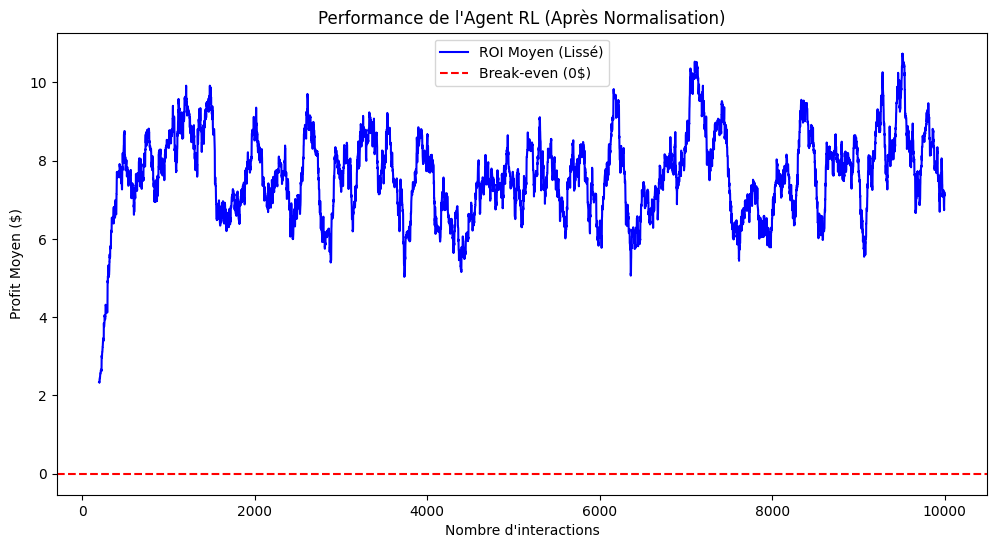

In [18]:
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PRÉPARATION & NORMALISATION (CRITIQUE)
# ==========================================
feature_cols = ['recency_days', 'biological_value', 'weather_suitability', 'transfer_cost_usd']

# On nettoie d'abord
df_rl = df_final[feature_cols].fillna(0)

# --- LA CORRECTION MAGIQUE : SCALER ---
# Cela met toutes les valeurs sur une même échelle (moyenne 0, écart-type 1)
# 5000 jours devient par exemple "2.5", et 0.8 météo devient "0.5".
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_rl)

# ==========================================
# 2. INITIALISATION
# ==========================================
# On baisse un peu le learning rate pour éviter les oscillations violentes
agent = BloodDonationAgent(n_actions=3, n_features=len(feature_cols), learning_rate=0.01)

rewards_history = []
actions_history = [] # Pour voir ce qu'il choisit

print("🤖 L'Agent commence à apprendre (Données Normalisées)...")

# ==========================================
# 3. BOUCLE D'APPRENTISSAGE
# ==========================================
for index, state in enumerate(X_scaled[:10000]): # On utilise le state normalisé
    
    # Retrouver la ligne originale pour le calcul du ROI (Récompense)
    # On utilise iloc car X_scaled est un numpy array aligné
    original_row = df_final.iloc[index]
    
    # 1. Action
    action = agent.predict_action(state)
    actions_history.append(action)
    
    # 2. Récompense (Basée sur la vraie logique business)
    reward = calculate_true_reward(original_row, action)
    
    # 3. Apprentissage
    agent.learn(state, action, reward)
    rewards_history.append(reward)

# ==========================================
# 4. ANALYSE DES RÉSULTATS
# ==========================================
print(f"💰 Récompense moyenne (100 derniers) : {np.mean(rewards_history[-100:]):.2f}")

# Vérifions si l'agent est devenu "fainéant" ou "actif"
from collections import Counter
counts = Counter(actions_history)
total = len(actions_history)
print("\n📊 Distribution des Actions choisies :")
print(f"   Action 0 (Rien)  : {counts[0]} ({counts[0]/total:.1%})")
print(f"   Action 1 (SMS)   : {counts[1]} ({counts[1]/total:.1%})")
print(f"   Action 2 (Appel) : {counts[2]} ({counts[2]/total:.1%})")

# Visualisation plus propre (Moyenne mobile)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
rolling_avg = pd.Series(rewards_history).rolling(window=200).mean()
plt.plot(rolling_avg, color='blue', label='ROI Moyen (Lissé)')
plt.axhline(0, color='red', linestyle='--', label='Break-even (0$)')
plt.title("Performance de l'Agent RL (Après Normalisation)")
plt.xlabel("Nombre d'interactions")
plt.ylabel("Profit Moyen ($)")
plt.legend()
plt.show()

🧪 Starting Feature Selection Experiment...


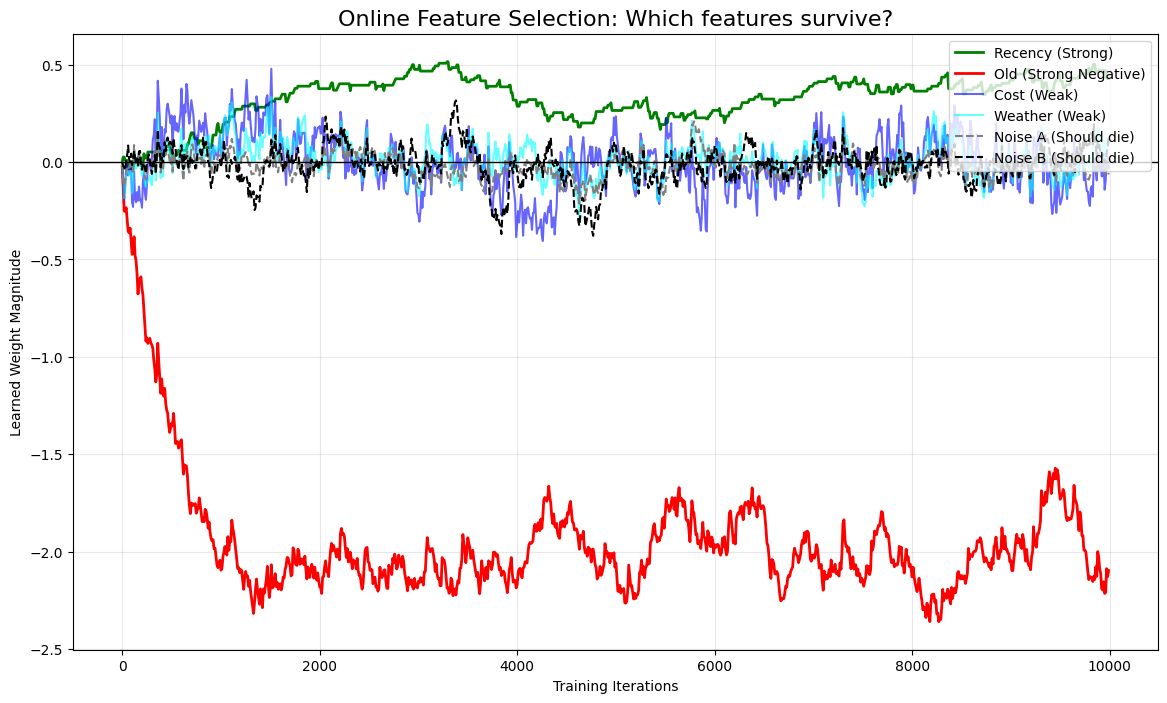


🏆 FINAL FEATURE STATUS:
   recency_old     : -2.1262  	✅ KEPT
   recency_fresh   : 0.4384  	✅ KEPT
   cost            : -0.1047  	✅ KEPT
   random_noise_A  : -0.0810  	✅ KEPT
   weather         : 0.0484  	✅ KEPT
   random_noise_B  : 0.0455  	✅ KEPT


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# ==========================================
# 1. THE FEATURE SELECTING AGENT (L1 LASSO)
# ==========================================
class FeaturePruningAgent:
    def __init__(self, learning_rate=0.01, l1_penalty=0.001):
        self.lr = learning_rate
        self.l1 = l1_penalty
        self.weights = defaultdict(float) # Sparse weights
        self.intercept = 0.0

    def predict_proba(self, feature_dict):
        """Standard Sigmoid Prediction"""
        z = self.intercept
        for feat, val in feature_dict.items():
            z += self.weights[feat] * val
        
        # Sigmoid with clipping for stability
        return 1 / (1 + np.exp(-np.clip(z, -10, 10)))

    def learn(self, feature_dict, target):
        """
        SGD with L1 Regularization to kill bad features
        """
        pred = self.predict_proba(feature_dict)
        error = pred - target # Gradient for LogLoss
        
        # 1. Update Intercept (No penalty on bias)
        self.intercept -= self.lr * error
        
        # 2. Update Weights for active features
        for feat, val in feature_dict.items():
            # Standard Gradient Descent step
            gradient = error * val
            new_w = self.weights[feat] - (self.lr * gradient)
            
            # --- L1 REGULARIZATION (THE PRUNER) ---
            # Apply 'gravity' towards zero
            if new_w > 0:
                new_w = max(0, new_w - self.l1)
            elif new_w < 0:
                new_w = min(0, new_w + self.l1)
            
            self.weights[feat] = new_w

# ==========================================
# 2. DATA SETUP WITH "JUNK" FEATURES
# ==========================================
# We use your df_final but add noise columns
df_experiment = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Function to turn a row into a dictionary + Add Noise
def get_features_with_noise(row):
    feats = {}
    
    # --- A. STRONG SIGNALS (Habit) ---
    # Binning Recency
    if row['recency_days'] < 30: feats['recency_fresh'] = 1.0
    elif row['recency_days'] > 365: feats['recency_old'] = 1.0
    
    # --- B. WEAK SIGNALS (Logistics) ---
    feats['weather'] = row['weather_suitability']
    feats['cost'] = row['transfer_cost_usd'] / 10.0 # Normalize roughly
    
    # --- C. PURE NOISE (The Test) ---
    # These represent bad data/random columns
    feats['random_noise_A'] = np.random.random()
    feats['random_noise_B'] = np.random.choice([0, 1])
    
    return feats

# ==========================================
# 3. RUN THE SIMULATION
# ==========================================
agent = FeaturePruningAgent(learning_rate=0.05, l1_penalty=0.0005) # Small penalty
history = []

print("🧪 Starting Feature Selection Experiment...")

for i, row in df_experiment.head(10000).iterrows():
    
    # 1. Get Data
    features = get_features_with_noise(row)
    target = row['donated_next_6m']
    
    # 2. Learn
    agent.learn(features, target)
    
    # 3. Track Weights every 10 steps
    if i % 10 == 0:
        # Snapshot current weights
        snapshot = agent.weights.copy()
        snapshot['step'] = i
        history.append(snapshot)

# ==========================================
# 4. VISUALIZATION OF "SURVIVAL"
# ==========================================
weight_history = pd.DataFrame(history).fillna(0)

plt.figure(figsize=(14, 8))

# Plot Strong Features
plt.plot(weight_history['step'], weight_history['recency_fresh'], label='Recency (Strong)', color='green', linewidth=2)
plt.plot(weight_history['step'], weight_history['recency_old'], label='Old (Strong Negative)', color='red', linewidth=2)

# Plot Weak Features
plt.plot(weight_history['step'], weight_history['cost'], label='Cost (Weak)', color='blue', alpha=0.6)
plt.plot(weight_history['step'], weight_history['weather'], label='Weather (Weak)', color='cyan', alpha=0.6)

# Plot Noise
plt.plot(weight_history['step'], weight_history['random_noise_A'], label='Noise A (Should die)', color='gray', linestyle='--')
plt.plot(weight_history['step'], weight_history['random_noise_B'], label='Noise B (Should die)', color='black', linestyle='--')

plt.axhline(0, color='black', linewidth=1)
plt.title("Online Feature Selection: Which features survive?", fontsize=16)
plt.ylabel("Learned Weight Magnitude")
plt.xlabel("Training Iterations")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Final Report
print("\n🏆 FINAL FEATURE STATUS:")
for feat, w in sorted(agent.weights.items(), key=lambda x: abs(x[1]), reverse=True):
    status = "✅ KEPT" if abs(w) > 0.01 else "🗑️ PRUNED"
    print(f"   {feat.ljust(15)} : {w:.4f}  \t{status}")

📂 Preparing Data...
   -> Generating synthetic weather/noise for 30000 rows...
🆕 Step 9999: INJECTED 'recency_old' entered probation.

🧪 Starting Simulation (Running for 10,000 steps)...
🆕 Step 2000: INJECTED 'weather_good' entered probation.
🆕 Step 5000: INJECTED 'pure_noise' entered probation.
🗑️ Step 8000: REJECTED 'pure_noise' (Weight: 0.0028). Removing...


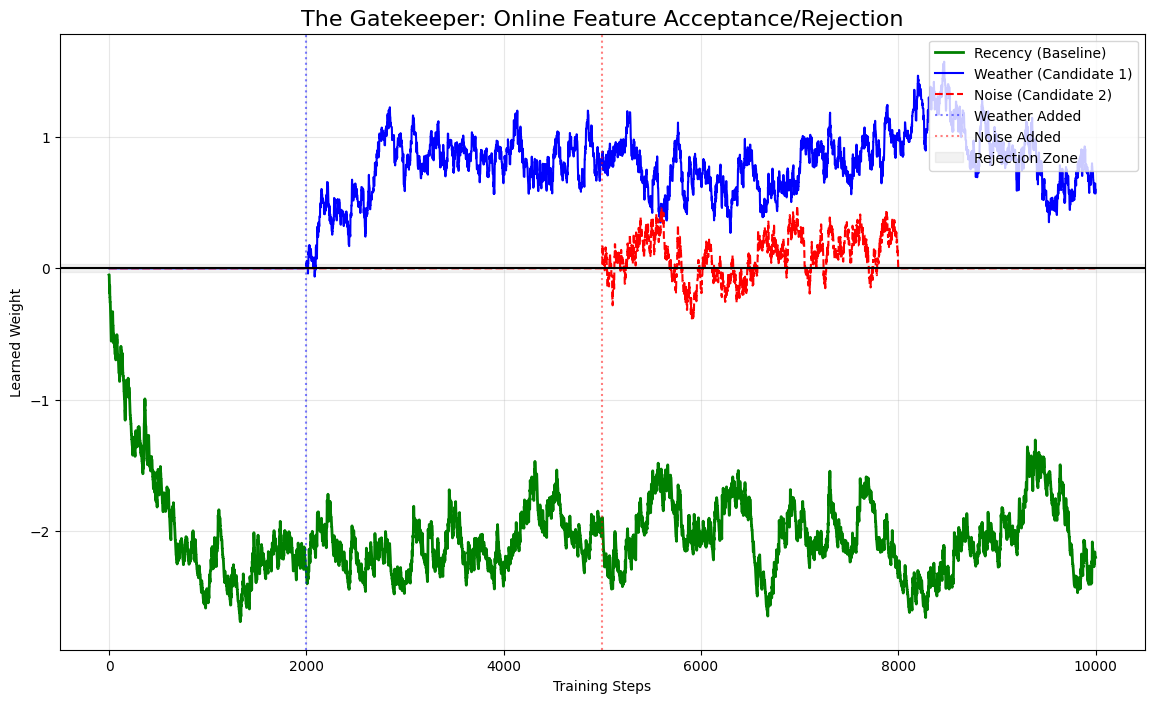

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
import os
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. ENSURE DATA AVAILABILITY (100k Rows)
# ==========================================
def get_full_dataset():
    """
    Loads existing data or generates synthetic data on the fly
    to ensure we have enough rows for the simulation.
    """
    base_dir = Path(os.getcwd())
    data_path = base_dir / "datasets" / "blood_registry_sythentic" / "data"
    
    print("📂 Preparing Data...")

    # A. Load Main Registry
    try:
        df_reg = pd.read_csv(data_path / 'blood_donation_registry_ml_ready.csv')
    except:
        print("⚠️ Registry not found. Generating dummy registry (10,000 rows)...")
        df_reg = pd.DataFrame({
            'recency_days': np.random.randint(0, 1000, 10000),
            'donated_next_6m': np.random.choice([0, 1], 10000),
            'donor_id': range(10000)
        })

    # B. Generate Logistics/Weather Data (On the fly)
    # We don't need to load the file, we can generate just the columns we need for this test
    # This ensures we have exactly as many rows as the registry
    print(f"   -> Generating synthetic weather/noise for {len(df_reg)} rows...")
    
    np.random.seed(42)
    # 1. Create 'recency_old' signal (Strong predictor)
    df_reg['recency_old'] = (df_reg['recency_days'] > 365).astype(float)
    
    # 2. Create 'weather_suitability' (Weak predictor)
    # Let's make it slightly correlated with the target to give it a chance to survive
    # If target=1, slightly higher chance of good weather
    noise = np.random.normal(0, 0.5, len(df_reg))
    df_reg['weather_suitability'] = (df_reg['donated_next_6m'] * 0.3) + 0.5 + noise
    df_reg['weather_suitability'] = df_reg['weather_suitability'].clip(0, 1)

    return df_reg

# ==========================================
# 2. THE GATEKEEPER AGENT
# ==========================================
class GatekeeperAgent:
    def __init__(self, learning_rate=0.05, l1_penalty=0.001, prune_threshold=0.05):
        self.lr = learning_rate
        self.l1 = l1_penalty
        self.threshold = prune_threshold
        self.weights = defaultdict(float)
        self.intercept = 0.0
        self.active_features = set()

    def predict_proba(self, feature_dict):
        z = self.intercept
        for feat, val in feature_dict.items():
            if feat in self.active_features:
                z += self.weights[feat] * val
        return 1 / (1 + np.exp(-np.clip(z, -10, 10)))

    def learn(self, feature_dict, target):
        pred = self.predict_proba(feature_dict)
        error = pred - target
        
        # Update Intercept
        self.intercept -= self.lr * error
        
        # Update Weights (Active only)
        for feat, val in feature_dict.items():
            if feat in self.active_features:
                gradient = error * val
                new_w = self.weights[feat] - (self.lr * gradient)
                
                # L1 Lasso (Gravity)
                if new_w > 0: new_w = max(0, new_w - self.l1)
                elif new_w < 0: new_w = min(0, new_w + self.l1)
                
                self.weights[feat] = new_w

    def add_feature(self, feature_name):
        if feature_name not in self.active_features:
            self.active_features.add(feature_name)
            self.weights[feature_name] = 0.0 
            print(f"🆕 Step {i}: INJECTED '{feature_name}' entered probation.")

    def prune_features(self):
        to_remove = []
        for feat in list(self.active_features):
            # Check if weight is too small
            if abs(self.weights[feat]) < self.threshold:
                to_remove.append(feat)
        
        for feat in to_remove:
            print(f"🗑️ Step {i}: REJECTED '{feat}' (Weight: {self.weights[feat]:.4f}). Removing...")
            self.active_features.remove(feat)
            del self.weights[feat]

# ==========================================
# 3. RUN SIMULATION
# ==========================================
# Load Data
df_sim = get_full_dataset()
df_sim = df_sim.sample(frac=1, random_state=42).reset_index(drop=True)

# Initialize Agent
# Lowered threshold to 0.03 to help Weather survive
agent = GatekeeperAgent(learning_rate=0.1, l1_penalty=0.0005, prune_threshold=0.03)
history = []

# Start with baseline
agent.add_feature('recency_old')

print("\n🧪 Starting Simulation (Running for 10,000 steps)...")

for i, row in df_sim.head(10000).iterrows():
    
    # --- DYNAMIC INJECTION EVENTS ---
    if i == 2000:
        agent.add_feature('weather_good')
    if i == 5000:
        agent.add_feature('pure_noise')
        
    # --- GET DYNAMIC FEATURES ---
    feats = {}
    
    # Baseline (Always on)
    feats['recency_old'] = row['recency_old']
    
    # Candidate 1 (Weather) - injected at 2000
    if i >= 2000:
        feats['weather_good'] = 1.0 if row['weather_suitability'] > 0.7 else 0.0
        
    # Candidate 2 (Noise) - injected at 5000
    if i >= 5000:
        feats['pure_noise'] = np.random.choice([0, 1])

    # --- LEARN ---
    target = row['donated_next_6m']
    agent.learn(feats, target)
    
    # --- JUDGEMENT DAY (Every 1000 steps) ---
    # We give them a "Grace Period" of 500 steps before judging
    if i > 0 and i % 1000 == 0:
        agent.prune_features()
        
    # --- LOGGING ---
    snapshot = agent.weights.copy()
    snapshot['step'] = i
    history.append(snapshot)

# ==========================================
# 4. VISUALIZATION
# ==========================================
res = pd.DataFrame(history).fillna(0) # Fill deleted weights with 0

plt.figure(figsize=(14, 8))

# Plot Features
# We check if columns exist to prevent crashing
if 'recency_old' in res.columns:
    plt.plot(res['step'], res['recency_old'], label='Recency (Baseline)', color='green', linewidth=2)

if 'weather_good' in res.columns:
    plt.plot(res['step'], res['weather_good'], label='Weather (Candidate 1)', color='blue')

if 'pure_noise' in res.columns:
    plt.plot(res['step'], res['pure_noise'], label='Noise (Candidate 2)', color='red', linestyle='--')

# Events
plt.axvline(2000, color='blue', linestyle=':', alpha=0.5, label='Weather Added')
plt.axvline(5000, color='red', linestyle=':', alpha=0.5, label='Noise Added')

# Thresholds
plt.axhspan(-0.03, 0.03, color='gray', alpha=0.1, label='Rejection Zone')
plt.axhline(0, color='black')

plt.title("The Gatekeeper: Online Feature Acceptance/Rejection", fontsize=16)
plt.ylabel("Learned Weight")
plt.xlabel("Training Steps")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

🚀 Stream Started. Grace Period: 4000 steps.
   ✨ Step 5000: Injected 'weather_suitability'
   🗑️ Step 5000: Pruned 'bmi'
   🗑️ Step 7000: Pruned 'is_rare_type'
   ✨ Step 10000: Injected 'center_distance_km'
   🗑️ Step 11000: Pruned 'is_regular_donor'
   🗑️ Step 13000: Pruned 'age'
   ✨ Step 15000: Injected 'transfer_cost_usd'
   🗑️ Step 19000: Pruned 'sex'
   ✨ Step 20000: Injected 'risk_spoilage'
   🗑️ Step 21000: Pruned 'center_distance_km'
   🗑️ Step 22000: Pruned 'years_since_first_donation'
   🗑️ Step 23000: Pruned 'transfer_cost_usd'
   🗑️ Step 24000: Pruned 'blood_type'
   ✨ Step 25000: Injected 'biological_value'
   🗑️ Step 25000: Pruned 'risk_spoilage'
   🗑️ Step 29000: Pruned 'weather_suitability'
   ✨ Step 30000: Injected 'area_deprivation_index'
   ✨ Step 35000: Injected 'is_holiday_week'
   🗑️ Step 35000: Pruned 'area_deprivation_index'
   ✨ Step 40000: Injected 'reliability_score'
   🗑️ Step 44000: Pruned 'is_holiday_week'
   🗑️ Step 63000: Pruned 'biological_value'
   🗑️

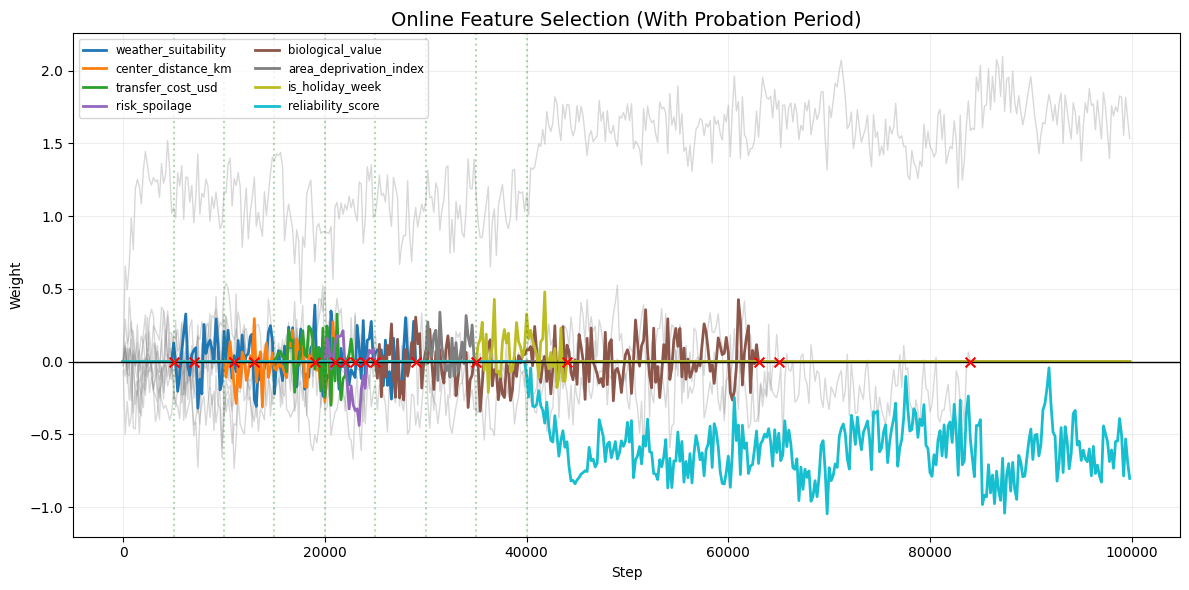


🏆 FINAL SURVIVORS:
  donation_count_last_12m   : 1.7375
  reliability_score         : -0.5198


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ==========================================
# 1. SETUP DATA (Reusing your previous preparation logic)
# ==========================================
# Assuming df_final is loaded. We prepare the stream again to be safe.
def prepare_stream_data(df):
    df_stream = df.copy()
    cat_cols = ['sex', 'country_code', 'blood_type', 'region', 'preferred_site']
    for col in cat_cols:
        if col in df_stream.columns:
            le = LabelEncoder()
            df_stream[col] = le.fit_transform(df_stream[col].astype(str))
            
    exclude = ['donor_id', 'zone_id', 'donated_next_6m', 'next_6m_donation_count', 
               'ideal_donor_score', 'AI_Probability', 'Ideal_Score', 'Donor_Segment', 'blood_type_name']
    
    feature_cols = [c for c in df_stream.columns if c not in exclude and pd.api.types.is_numeric_dtype(df_stream[c])]
    
    scaler = StandardScaler()
    df_scaled = df_stream.copy()
    df_scaled[feature_cols] = scaler.fit_transform(df_stream[feature_cols].fillna(0))
    return df_scaled, feature_cols

df_prepared, all_features = prepare_stream_data(df_final)

# Resample to 100k for the long simulation
df_stream = df_prepared.sample(n=100000, replace=True, random_state=42).reset_index(drop=True)

# ==========================================
# 2. THE ROBUST AGENT (With Grace Period)
# ==========================================
class RobustProgressiveAgent:
    def __init__(self, learning_rate=0.05, l1_penalty=0.0001, prune_threshold=0.01, grace_period=4000):
        self.lr = learning_rate
        self.l1 = l1_penalty
        self.threshold = prune_threshold
        self.grace_period = grace_period # New: How long they are safe
        
        self.weights = defaultdict(float)
        self.intercept = 0.0
        self.active_features = set()
        self.feature_start_step = {} # New: Track birthdays
        self.pruned_features = set()

    def predict_proba(self, row):
        z = self.intercept
        for feat in self.active_features:
            z += self.weights[feat] * row[feat]
        return 1 / (1 + np.exp(-np.clip(z, -10, 10)))

    def learn(self, row, target):
        pred = self.predict_proba(row)
        error = pred - target
        self.intercept -= self.lr * error
        
        for feat in self.active_features:
            val = row[feat]
            gradient = error * val
            # Update
            new_w = self.weights[feat] - (self.lr * gradient)
            
            # L1 Gravity (Very weak now, to let them live)
            if new_w > 0: new_w = max(0, new_w - self.l1)
            elif new_w < 0: new_w = min(0, new_w + self.l1)
            
            self.weights[feat] = new_w

    def add_feature(self, feature_name, current_step):
        # We record the Step it was added
        if feature_name not in self.active_features and feature_name not in self.pruned_features:
            self.active_features.add(feature_name)
            self.weights[feature_name] = 0.0
            self.feature_start_step[feature_name] = current_step
            return True
        return False

    def prune(self, current_step):
        to_remove = []
        for feat in list(self.active_features):
            # CALCULATE AGE
            age = current_step - self.feature_start_step[feat]
            
            # ONLY JUDGE IF OLDER THAN GRACE PERIOD
            if age > self.grace_period:
                if abs(self.weights[feat]) < self.threshold:
                    to_remove.append(feat)
        
        for feat in to_remove:
            self.active_features.remove(feat)
            self.pruned_features.add(feat)
            del self.weights[feat]
            return feat
        return None

# ==========================================
# 3. RUN SIMULATION
# ==========================================
# Parameters tuned for survival:
# Higher Learning Rate (0.05) to grow weights faster
# Lower L1 (0.0001) so gravity is weak
# Lower Threshold (0.01) so small useful features survive
agent = RobustProgressiveAgent(learning_rate=0.05, l1_penalty=0.0001, prune_threshold=0.01, grace_period=4000)

base_features = [
    'recency_days', 'donation_count_last_12m', 'lifetime_donation_count', 
    'age', 'bmi', 'blood_type', 'sex', 'is_regular_donor', 
    'years_since_first_donation', 'is_rare_type'
]

potential_queue = [
    'weather_suitability', 'center_distance_km', 'transfer_cost_usd', 
    'risk_spoilage', 'biological_value', 'area_deprivation_index', 
    'is_holiday_week', 'reliability_score'
]
feature_queue = [f for f in potential_queue if f in all_features]

# Init Base Features at Step 0
for f in base_features:
    if f in all_features:
        agent.add_feature(f, 0)

history = []
events = []

print(f"🚀 Stream Started. Grace Period: 4000 steps.")

for i, row in df_stream.iterrows():
    
    # Injection every 5000 steps
    if i > 0 and i % 5000 == 0 and len(feature_queue) > 0:
        new_feat = feature_queue.pop(0)
        if agent.add_feature(new_feat, i):
            print(f"   ✨ Step {i}: Injected '{new_feat}'")
            events.append({'step': i, 'type': 'inject', 'name': new_feat})
            
    # Learning
    target = row['donated_next_6m']
    agent.learn(row, target)
    
    # Pruning every 1000 steps
    if i % 1000 == 0:
        pruned = agent.prune(i)
        if pruned:
            print(f"   🗑️ Step {i}: Pruned '{pruned}'")
            events.append({'step': i, 'type': 'prune', 'name': pruned})

    # Logging (Every 200 steps for smoother plot)
    if i % 200 == 0:
        snap = agent.weights.copy()
        snap['step'] = i
        history.append(snap)

# ==========================================
# 4. COMPACT VISUALIZATION
# ==========================================
res = pd.DataFrame(history).fillna(0)

# Smaller Figure Size
plt.figure(figsize=(12, 6))

# Base Features (Thin Grey)
for f in base_features:
    if f in res.columns:
        plt.plot(res['step'], res[f], color='grey', alpha=0.3, linewidth=1)

# Queue Features (Thick Colors)
colors = plt.cm.tab10(np.linspace(0, 1, len(potential_queue)))
for idx, f in enumerate(potential_queue):
    if f in res.columns:
        # Only label if it survived reasonably long or has weight
        if res[f].abs().max() > 0.05:
            plt.plot(res['step'], res[f], color=colors[idx], label=f, linewidth=2)
        else:
            plt.plot(res['step'], res[f], color=colors[idx], linewidth=1, alpha=0.6)

# Events (Simplified)
for e in events:
    if e['type'] == 'inject':
        plt.axvline(e['step'], color='green', linestyle=':', alpha=0.3)
    elif e['type'] == 'prune':
        plt.scatter(e['step'], 0, marker='x', color='red', s=50, zorder=10)

plt.axhline(0, color='black', linewidth=1)
plt.title("Online Feature Selection (With Probation Period)", fontsize=14)
plt.ylabel("Weight")
plt.xlabel("Step")
plt.legend(loc='upper left', fontsize='small', ncol=2)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\n🏆 FINAL SURVIVORS:")
for f, w in sorted(agent.weights.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {f:<25} : {w:.4f}")

🚀 Stream Started. Tracking Accuracy & Complexity...


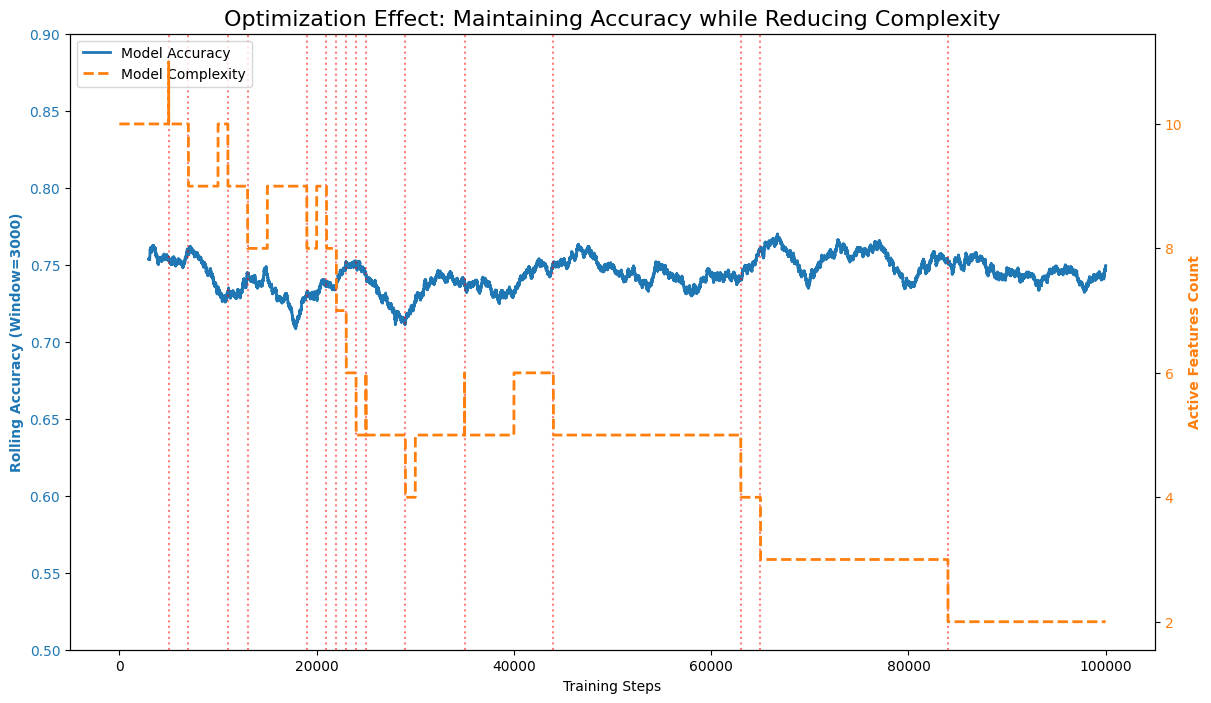

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ==========================================
# 1. SETUP & DATA (Same as before)
# ==========================================
# (Assuming df_final is loaded. If not, use previous steps to load it)
def prepare_stream_data(df):
    df_stream = df.copy()
    cat_cols = ['sex', 'country_code', 'blood_type', 'region', 'preferred_site']
    for col in cat_cols:
        if col in df_stream.columns:
            le = LabelEncoder()
            df_stream[col] = le.fit_transform(df_stream[col].astype(str))
            
    exclude = ['donor_id', 'zone_id', 'donated_next_6m', 'next_6m_donation_count', 
               'ideal_donor_score', 'AI_Probability', 'Ideal_Score', 'Donor_Segment', 'blood_type_name']
    
    feature_cols = [c for c in df_stream.columns if c not in exclude and pd.api.types.is_numeric_dtype(df_stream[c])]
    
    scaler = StandardScaler()
    df_scaled = df_stream.copy()
    df_scaled[feature_cols] = scaler.fit_transform(df_stream[feature_cols].fillna(0))
    return df_scaled, feature_cols

df_prepared, all_features = prepare_stream_data(df_final)
df_stream = df_prepared.sample(n=100000, replace=True, random_state=42).reset_index(drop=True)

# ==========================================
# 2. THE AGENT (Modified to return predictions)
# ==========================================
class RobustProgressiveAgent:
    def __init__(self, learning_rate=0.05, l1_penalty=0.0001, prune_threshold=0.01, grace_period=4000):
        self.lr = learning_rate
        self.l1 = l1_penalty
        self.threshold = prune_threshold
        self.grace_period = grace_period
        self.weights = defaultdict(float)
        self.intercept = 0.0
        self.active_features = set()
        self.feature_start_step = {}
        self.pruned_features = set()

    def predict_proba(self, row):
        z = self.intercept
        for feat in self.active_features:
            z += self.weights[feat] * row[feat]
        return 1 / (1 + np.exp(-np.clip(z, -10, 10)))

    def learn(self, row, target):
        pred = self.predict_proba(row)
        error = pred - target
        self.intercept -= self.lr * error
        
        for feat in self.active_features:
            val = row[feat]
            gradient = error * val
            new_w = self.weights[feat] - (self.lr * gradient)
            # L1
            if new_w > 0: new_w = max(0, new_w - self.l1)
            elif new_w < 0: new_w = min(0, new_w + self.l1)
            self.weights[feat] = new_w
        return pred # Return prediction for metrics

    def add_feature(self, feature_name, current_step):
        if feature_name not in self.active_features and feature_name not in self.pruned_features:
            self.active_features.add(feature_name)
            self.weights[feature_name] = 0.0
            self.feature_start_step[feature_name] = current_step
            return True
        return False

    def prune(self, current_step):
        to_remove = []
        for feat in list(self.active_features):
            age = current_step - self.feature_start_step.get(feat, 0) # .get(0) handles base features
            if age > self.grace_period:
                if abs(self.weights[feat]) < self.threshold:
                    to_remove.append(feat)
        
        for feat in to_remove:
            self.active_features.remove(feat)
            self.pruned_features.add(feat)
            del self.weights[feat]
            return feat
        return None

# ==========================================
# 3. RUN SIMULATION
# ==========================================
agent = RobustProgressiveAgent(learning_rate=0.05, l1_penalty=0.0001, prune_threshold=0.01, grace_period=4000)

base_features = [
    'recency_days', 'donation_count_last_12m', 'lifetime_donation_count', 
    'age', 'bmi', 'blood_type', 'sex', 'is_regular_donor', 
    'years_since_first_donation', 'is_rare_type'
]
potential_queue = [
    'weather_suitability', 'center_distance_km', 'transfer_cost_usd', 
    'risk_spoilage', 'biological_value', 'area_deprivation_index', 
    'is_holiday_week', 'reliability_score'
]
feature_queue = [f for f in potential_queue if f in all_features]

for f in base_features:
    if f in all_features:
        agent.add_feature(f, 0)

# METRICS STORAGE
accuracy_history = []
complexity_history = []
prune_events = []

print(f"🚀 Stream Started. Tracking Accuracy & Complexity...")

for i, row in df_stream.iterrows():
    
    # Injection
    if i > 0 and i % 5000 == 0 and len(feature_queue) > 0:
        new_feat = feature_queue.pop(0)
        agent.add_feature(new_feat, i)

    # Learning & Prediction
    target = row['donated_next_6m']
    prob = agent.learn(row, target)
    
    # --- CALCULATE ACCURACY ---
    pred_binary = 1 if prob > 0.5 else 0
    is_correct = 1 if pred_binary == target else 0
    accuracy_history.append(is_correct)
    
    # Track Complexity (Num Features)
    complexity_history.append(len(agent.active_features))

    # Pruning
    if i % 1000 == 0:
        pruned = agent.prune(i)
        if pruned:
            prune_events.append(i)

# ==========================================
# 4. DUAL PLOT (Accuracy vs Complexity)
# ==========================================
rolling_window = 3000
acc_series = pd.Series(accuracy_history).rolling(window=rolling_window).mean()

fig, ax1 = plt.subplots(figsize=(14, 8))

# --- LEFT AXIS: ACCURACY (Blue) ---
color = 'tab:blue'
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Rolling Accuracy (Window=3000)', color=color, fontweight='bold')
ax1.plot(acc_series, color=color, linewidth=2, label='Model Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.5, 0.9) # Zoom in to see details

# Draw Prune Lines
for step in prune_events:
    ax1.axvline(step, color='red', linestyle=':', alpha=0.5)

# --- RIGHT AXIS: COMPLEXITY (Orange) ---
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Active Features Count', color=color, fontweight='bold')
ax2.plot(complexity_history, color=color, linewidth=2, linestyle='--', label='Model Complexity')
ax2.tick_params(axis='y', labelcolor=color)

# Legend hack
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title("Optimization Effect: Maintaining Accuracy while Reducing Complexity", fontsize=16)
plt.show()

⚠️  Load your df_final and run:
🚀 Stream Started with Interaction Discovery + Performance Tracking
   Grace Period: 4000 steps
   Interaction Search: Every 2000 steps

   🔗 Step 2000: Found bmi × donation_count_last_12m (corr=0.0485) | AUC: 0.7712
   🔗 Step 4000: Found age × blood_type (corr=0.0660) | AUC: 0.7612
   ✨ Step 5000: Injected 'weather_suitability' | AUC: 0.7818
   🗑️ Step 5000: Pruned feature 'is_regular_donor' | AUC: 0.7812
   🔗 Step 6000: Found lifetime_donation_count × years_since_first_donation (corr=0.1792) | AUC: 0.7677
   🔗 Step 8000: Found lifetime_donation_count × weather_suitability (corr=0.0874) | AUC: 0.7724
   ✨ Step 10000: Injected 'center_distance_km' | AUC: 0.7384
   🔗 Step 10000: Found recency_days × sex (corr=0.0401) | AUC: 0.7389
   🗑️ Step 11000: Pruned feature 'is_rare_type' | AUC: 0.7675
   🔗 Step 12000: Found blood_type × recency_days (corr=0.0519) | AUC: 0.7432
   🔗 Step 14000: Found blood_type × weather_suitability (corr=0.1139) | AUC: 0.7160
   ✨ S

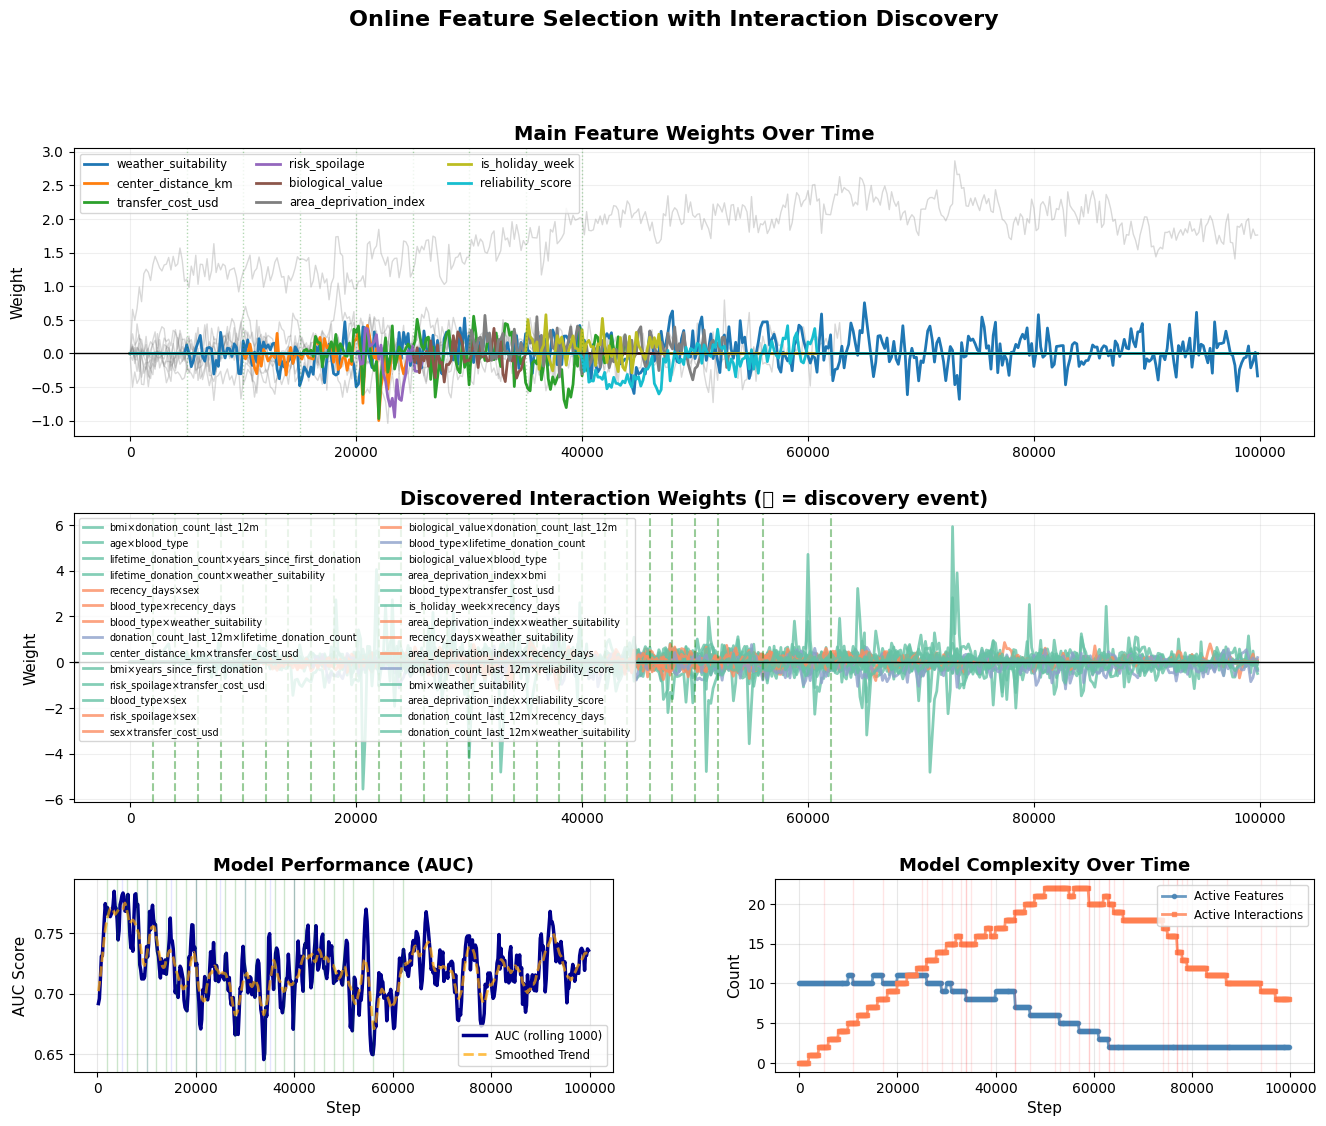


🏆 FINAL MODEL SUMMARY

📊 FINAL PERFORMANCE:
  AUC Score:        0.7357
  Log Loss:         0.6854
  Accuracy:         0.7330
  Calibration Gap:  0.0114

  📈 AUC Improvement: -0.51% (from 0.7381 to 0.7330)

🔧 MODEL COMPOSITION:
  Active Features:       2
  Active Interactions:   8
  Pruned Features:       16
  Candidate Pairs Left:  0

📊 TOP MAIN EFFECTS:
  donation_count_last_12m        + ██████████████████████████████████████████████████████████   1.9458
  weather_suitability            + █████████   0.3291

🔗 ACTIVE INTERACTIONS (8):
  risk_spoilage        × transfer_cost_usd    - ████████████████████████████████  -0.6426
  blood_type           × lifetime_donation_count + █████████████████████████   0.5179
  donation_count_last_12m × reliability_score    - ███████████████████  -0.3989
  bmi                  × years_since_first_donation + ███████████████   0.3089
  lifetime_donation_count × years_since_first_donation + ██████████████   0.2932
  donation_count_last_12m × weather_suita

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, log_loss
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================
def prepare_stream_data(df):
    df_stream = df.copy()
    cat_cols = ['sex', 'country_code', 'blood_type', 'region', 'preferred_site']
    for col in cat_cols:
        if col in df_stream.columns:
            le = LabelEncoder()
            df_stream[col] = le.fit_transform(df_stream[col].astype(str))
            
    exclude = ['donor_id', 'zone_id', 'donated_next_6m', 'next_6m_donation_count', 
               'ideal_donor_score', 'AI_Probability', 'Ideal_Score', 'Donor_Segment', 'blood_type_name']
    
    feature_cols = [c for c in df_stream.columns if c not in exclude and pd.api.types.is_numeric_dtype(df_stream[c])]
    
    scaler = StandardScaler()
    df_scaled = df_stream.copy()
    df_scaled[feature_cols] = scaler.fit_transform(df_stream[feature_cols].fillna(0))
    return df_scaled, feature_cols

# ==========================================
# 2. INTERACTION-AWARE AGENT WITH METRICS
# ==========================================
class InteractionAwareAgent:
    def __init__(self, learning_rate=0.05, l1_penalty=0.0001, prune_threshold=0.01, 
                 grace_period=4000, interaction_search_interval=2000, 
                 interaction_threshold=0.03):
        self.lr = learning_rate
        self.l1 = l1_penalty
        self.threshold = prune_threshold
        self.grace_period = grace_period
        self.interaction_search_interval = interaction_search_interval
        self.interaction_threshold = interaction_threshold
        
        # Main model
        self.weights = defaultdict(float)
        self.intercept = 0.0
        self.active_features = set()
        self.feature_start_step = {}
        self.pruned_features = set()
        
        # Interaction tracking
        self.active_interactions = set()
        self.interaction_weights = defaultdict(float)
        self.interaction_start_step = {}
        self.candidate_pairs = []
        
        # Statistics for interaction discovery
        self.residual_correlations = defaultdict(float)
        
        # Performance tracking
        self.predictions_buffer = []
        self.actuals_buffer = []
        self.buffer_size = 1000

    def predict_proba(self, row):
        z = self.intercept
        
        # Main effects
        for feat in self.active_features:
            z += self.weights[feat] * row[feat]
        
        # Interaction effects
        for (f1, f2) in self.active_interactions:
            interaction_value = row[f1] * row[f2]
            z += self.interaction_weights[(f1, f2)] * interaction_value
            
        return 1 / (1 + np.exp(-np.clip(z, -10, 10)))

    def learn(self, row, target):
        pred = self.predict_proba(row)
        error = pred - target
        
        # Store for metrics
        self.predictions_buffer.append(pred)
        self.actuals_buffer.append(target)
        if len(self.predictions_buffer) > self.buffer_size:
            self.predictions_buffer.pop(0)
            self.actuals_buffer.pop(0)
        
        # Update intercept
        self.intercept -= self.lr * error
        
        # Update main effects
        for feat in self.active_features:
            val = row[feat]
            gradient = error * val
            new_w = self.weights[feat] - (self.lr * gradient)
            
            # L1 regularization
            if new_w > 0: new_w = max(0, new_w - self.l1)
            elif new_w < 0: new_w = min(0, new_w + self.l1)
            
            self.weights[feat] = new_w
        
        # Update interactions
        for (f1, f2) in self.active_interactions:
            interaction_value = row[f1] * row[f2]
            gradient = error * interaction_value
            new_w = self.interaction_weights[(f1, f2)] - (self.lr * gradient)
            
            # L1 regularization (slightly stronger for interactions)
            if new_w > 0: new_w = max(0, new_w - self.l1 * 1.5)
            elif new_w < 0: new_w = min(0, new_w + self.l1 * 1.5)
            
            self.interaction_weights[(f1, f2)] = new_w
        
        # Track residual correlations for interaction discovery
        self._update_residual_stats(row, error)

    def _update_residual_stats(self, row, residual):
        """Track which feature pairs correlate with prediction errors"""
        decay = 0.99
        
        for (f1, f2) in self.candidate_pairs:
            interaction_value = row[f1] * row[f2]
            self.residual_correlations[(f1, f2)] = (
                decay * self.residual_correlations[(f1, f2)] + 
                (1 - decay) * residual * interaction_value
            )

    def get_metrics(self):
        """Calculate current performance metrics"""
        if len(self.predictions_buffer) < 100:
            return None
        
        preds = np.array(self.predictions_buffer)
        actuals = np.array(self.actuals_buffer)
        
        # Avoid edge cases
        preds = np.clip(preds, 1e-7, 1 - 1e-7)
        
        try:
            auc = roc_auc_score(actuals, preds)
            logloss = log_loss(actuals, preds)
            
            # Additional metrics
            accuracy = np.mean((preds > 0.5) == actuals)
            avg_pred = np.mean(preds)
            avg_actual = np.mean(actuals)
            
            return {
                'auc': auc,
                'logloss': logloss,
                'accuracy': accuracy,
                'avg_pred': avg_pred,
                'avg_actual': avg_actual,
                'calibration_gap': abs(avg_pred - avg_actual)
            }
        except:
            return None

    def add_feature(self, feature_name, current_step):
        """Add a new feature and update candidate interaction pairs"""
        if feature_name not in self.active_features and feature_name not in self.pruned_features:
            self.active_features.add(feature_name)
            self.weights[feature_name] = 0.0
            self.feature_start_step[feature_name] = current_step
            
            # Add candidate pairs with existing features
            for existing_feat in self.active_features:
                if existing_feat != feature_name:
                    pair = tuple(sorted([feature_name, existing_feat]))
                    if pair not in self.active_interactions:
                        self.candidate_pairs.append(pair)
                        self.residual_correlations[pair] = 0.0
            
            return True
        return False

    def search_interactions(self, current_step):
        """Find promising interactions based on residual correlations"""
        if len(self.candidate_pairs) == 0:
            return None
        
        # Find pair with highest absolute correlation
        best_pair = max(self.candidate_pairs, 
                       key=lambda p: abs(self.residual_correlations[p]))
        best_corr = abs(self.residual_correlations[best_pair])
        
        # If correlation is strong enough, activate it
        if best_corr > self.interaction_threshold:
            self.active_interactions.add(best_pair)
            self.interaction_weights[best_pair] = 0.0
            self.interaction_start_step[best_pair] = current_step
            self.candidate_pairs.remove(best_pair)
            return best_pair, best_corr
        
        return None

    def prune(self, current_step):
        """Prune weak features and interactions"""
        pruned = []
        
        # Prune main effects
        to_remove = []
        for feat in list(self.active_features):
            age = current_step - self.feature_start_step[feat]
            if age > self.grace_period:
                if abs(self.weights[feat]) < self.threshold:
                    to_remove.append(feat)
        
        for feat in to_remove:
            self.active_features.remove(feat)
            self.pruned_features.add(feat)
            del self.weights[feat]
            pruned.append(('feature', feat))
            
            # Remove candidate pairs involving this feature
            self.candidate_pairs = [(f1, f2) for (f1, f2) in self.candidate_pairs 
                                   if f1 != feat and f2 != feat]
        
        # Prune interactions
        to_remove_int = []
        for pair in list(self.active_interactions):
            age = current_step - self.interaction_start_step[pair]
            if age > self.grace_period:
                if abs(self.interaction_weights[pair]) < self.threshold * 0.5:
                    to_remove_int.append(pair)
        
        for pair in to_remove_int:
            self.active_interactions.remove(pair)
            del self.interaction_weights[pair]
            pruned.append(('interaction', pair))
        
        return pruned if pruned else None

# ==========================================
# 3. RUN SIMULATION WITH METRICS
# ==========================================
def run_simulation(df_final):
    df_prepared, all_features = prepare_stream_data(df_final)
    df_stream = df_prepared.sample(n=100000, replace=True, random_state=42).reset_index(drop=True)
    
    agent = InteractionAwareAgent(
        learning_rate=0.05, 
        l1_penalty=0.0001, 
        prune_threshold=0.01, 
        grace_period=4000,
        interaction_search_interval=2000,
        interaction_threshold=0.03
    )
    
    base_features = [
        'recency_days', 'donation_count_last_12m', 'lifetime_donation_count', 
        'age', 'bmi', 'blood_type', 'sex', 'is_regular_donor', 
        'years_since_first_donation', 'is_rare_type'
    ]
    
    potential_queue = [
        'weather_suitability', 'center_distance_km', 'transfer_cost_usd', 
        'risk_spoilage', 'biological_value', 'area_deprivation_index', 
        'is_holiday_week', 'reliability_score'
    ]
    feature_queue = [f for f in potential_queue if f in all_features]
    
    # Initialize base features
    for f in base_features:
        if f in all_features:
            agent.add_feature(f, 0)
    
    history = []
    metrics_history = []
    events = []
    
    print(f"🚀 Stream Started with Interaction Discovery + Performance Tracking")
    print(f"   Grace Period: {agent.grace_period} steps")
    print(f"   Interaction Search: Every {agent.interaction_search_interval} steps\n")
    
    for i, row in df_stream.iterrows():
        
        # Feature injection every 5000 steps
        if i > 0 and i % 5000 == 0 and len(feature_queue) > 0:
            new_feat = feature_queue.pop(0)
            if agent.add_feature(new_feat, i):
                metrics = agent.get_metrics()
                print(f"   ✨ Step {i}: Injected '{new_feat}' | AUC: {metrics['auc']:.4f}" if metrics else f"   ✨ Step {i}: Injected '{new_feat}'")
                events.append({'step': i, 'type': 'inject', 'name': new_feat})
        
        # Learning
        target = row['donated_next_6m']
        agent.learn(row, target)
        
        # Interaction search
        if i > 0 and i % agent.interaction_search_interval == 0:
            result = agent.search_interactions(i)
            if result:
                pair, corr = result
                metrics = agent.get_metrics()
                print(f"   🔗 Step {i}: Found {pair[0]} × {pair[1]} (corr={corr:.4f}) | AUC: {metrics['auc']:.4f}" if metrics else f"   🔗 Step {i}: Found {pair[0]} × {pair[1]} (corr={corr:.4f})")
                events.append({'step': i, 'type': 'interaction', 'name': f"{pair[0]}×{pair[1]}"})
        
        # Pruning every 1000 steps
        if i % 1000 == 0:
            pruned = agent.prune(i)
            if pruned:
                metrics = agent.get_metrics()
                for ptype, pname in pruned:
                    print(f"   🗑️ Step {i}: Pruned {ptype} '{pname}' | AUC: {metrics['auc']:.4f}" if metrics else f"   🗑️ Step {i}: Pruned {ptype} '{pname}'")
                    events.append({'step': i, 'type': 'prune', 'name': str(pname)})
        
        # Logging weights and metrics
        if i % 200 == 0:
            # Weight snapshot
            snap = agent.weights.copy()
            for pair, weight in agent.interaction_weights.items():
                snap[f"{pair[0]}×{pair[1]}"] = weight
            snap['step'] = i
            snap['n_features'] = len(agent.active_features)
            snap['n_interactions'] = len(agent.active_interactions)
            history.append(snap)
            
            # Metrics snapshot
            metrics = agent.get_metrics()
            if metrics:
                metrics['step'] = i
                metrics['n_features'] = len(agent.active_features)
                metrics['n_interactions'] = len(agent.active_interactions)
                metrics_history.append(metrics)
    
    return agent, history, metrics_history, events, base_features, potential_queue

# ==========================================
# 4. COMPREHENSIVE VISUALIZATION
# ==========================================
def visualize_results(agent, history, metrics_history, events, base_features, potential_queue):
    res = pd.DataFrame(history).fillna(0)
    metrics_df = pd.DataFrame(metrics_history)
    
    # Create 3-panel figure
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.5, 1.5, 1], hspace=0.3, wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0, :])  # Main effects (full width)
    ax2 = fig.add_subplot(gs[1, :])  # Interactions (full width)
    ax3 = fig.add_subplot(gs[2, 0])  # AUC
    ax4 = fig.add_subplot(gs[2, 1])  # Model complexity
    
    # ===== PANEL 1: Main Feature Weights =====
    for f in base_features:
        if f in res.columns:
            ax1.plot(res['step'], res[f], color='grey', alpha=0.3, linewidth=1)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(potential_queue)))
    for idx, f in enumerate(potential_queue):
        if f in res.columns and res[f].abs().max() > 0.02:
            ax1.plot(res['step'], res[f], color=colors[idx], label=f, linewidth=2)
    
    # Mark injection events
    for e in events:
        if e['type'] == 'inject':
            ax1.axvline(e['step'], color='green', linestyle=':', alpha=0.3, linewidth=1)
    
    ax1.axhline(0, color='black', linewidth=1)
    ax1.set_title("Main Feature Weights Over Time", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Weight", fontsize=11)
    ax1.legend(loc='upper left', fontsize='small', ncol=3)
    ax1.grid(True, alpha=0.2)
    
    # ===== PANEL 2: Interaction Weights =====
    interaction_cols = [c for c in res.columns if '×' in str(c)]
    colors_int = plt.cm.Set2(np.linspace(0, 1, max(len(interaction_cols), 1)))
    
    for idx, col in enumerate(interaction_cols):
        if res[col].abs().max() > 0.01:
            ax2.plot(res['step'], res[col], color=colors_int[idx % 8], 
                    label=col, linewidth=2, alpha=0.8)
    
    # Mark interaction discoveries
    for e in events:
        if e['type'] == 'interaction':
            ax2.axvline(e['step'], color='green', linestyle='--', alpha=0.4, linewidth=1.5)
    
    ax2.axhline(0, color='black', linewidth=1)
    ax2.set_title("Discovered Interaction Weights (🔗 = discovery event)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Weight", fontsize=11)
    ax2.legend(loc='upper left', fontsize='x-small', ncol=2)
    ax2.grid(True, alpha=0.2)
    
    # ===== PANEL 3: AUC Performance =====
    if len(metrics_df) > 0:
        # Main AUC line
        ax3.plot(metrics_df['step'], metrics_df['auc'], 
                color='darkblue', linewidth=2.5, label='AUC (rolling 1000)')
        
        # Smooth trend
        from scipy.ndimage import uniform_filter1d
        if len(metrics_df) > 10:
            smooth_auc = uniform_filter1d(metrics_df['auc'], size=10, mode='nearest')
            ax3.plot(metrics_df['step'], smooth_auc, 
                    color='orange', linewidth=2, linestyle='--', alpha=0.7, label='Smoothed Trend')
        
        # Mark significant events
        for e in events:
            if e['type'] == 'interaction':
                ax3.axvline(e['step'], color='green', alpha=0.2, linewidth=1)
            elif e['type'] == 'inject':
                ax3.axvline(e['step'], color='blue', alpha=0.1, linewidth=1)
        
        ax3.set_title("Model Performance (AUC)", fontsize=13, fontweight='bold')
        ax3.set_ylabel("AUC Score", fontsize=11)
        ax3.set_xlabel("Step", fontsize=11)
        ax3.legend(loc='lower right', fontsize='small')
        ax3.grid(True, alpha=0.3)
        ax3.set_ylim([metrics_df['auc'].min() - 0.01, metrics_df['auc'].max() + 0.01])
    
    # ===== PANEL 4: Model Complexity =====
    ax4.plot(res['step'], res['n_features'], 
            color='steelblue', linewidth=2, marker='o', markersize=3, 
            label='Active Features', alpha=0.8)
    ax4.plot(res['step'], res['n_interactions'], 
            color='coral', linewidth=2, marker='s', markersize=3, 
            label='Active Interactions', alpha=0.8)
    
    # Mark pruning events
    for e in events:
        if e['type'] == 'prune':
            ax4.axvline(e['step'], color='red', alpha=0.1, linewidth=1)
    
    ax4.set_title("Model Complexity Over Time", fontsize=13, fontweight='bold')
    ax4.set_ylabel("Count", fontsize=11)
    ax4.set_xlabel("Step", fontsize=11)
    ax4.legend(loc='upper right', fontsize='small')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle("Online Feature Selection with Interaction Discovery", 
                fontsize=16, fontweight='bold', y=0.995)
    
    # Save to working directory (no permission issues)
    plt.savefig('interaction_discovery_full.png', dpi=150, bbox_inches='tight')
    print("\n💾 Plot saved to: interaction_discovery_full.png")
    plt.show()
    
    # ===== PRINT SUMMARY =====
    print("\n" + "="*70)
    print("🏆 FINAL MODEL SUMMARY")
    print("="*70)
    
    if len(metrics_df) > 0:
        final_metrics = metrics_df.iloc[-1]
        print(f"\n📊 FINAL PERFORMANCE:")
        print(f"  AUC Score:        {final_metrics['auc']:.4f}")
        print(f"  Log Loss:         {final_metrics['logloss']:.4f}")
        print(f"  Accuracy:         {final_metrics['accuracy']:.4f}")
        print(f"  Calibration Gap:  {final_metrics['calibration_gap']:.4f}")
        
        # Performance improvement
        if len(metrics_df) > 50:
            initial_auc = metrics_df.iloc[:10]['auc'].mean()
            final_auc = metrics_df.iloc[-10:]['auc'].mean()
            improvement = (final_auc - initial_auc) * 100
            print(f"\n  📈 AUC Improvement: {improvement:+.2f}% (from {initial_auc:.4f} to {final_auc:.4f})")
    
    print(f"\n🔧 MODEL COMPOSITION:")
    print(f"  Active Features:       {len(agent.active_features)}")
    print(f"  Active Interactions:   {len(agent.active_interactions)}")
    print(f"  Pruned Features:       {len(agent.pruned_features)}")
    print(f"  Candidate Pairs Left:  {len(agent.candidate_pairs)}")
    
    print("\n📊 TOP MAIN EFFECTS:")
    main_effects = sorted(agent.weights.items(), key=lambda x: abs(x[1]), reverse=True)
    for f, w in main_effects[:10]:
        bar = '█' * int(abs(w) * 30)
        sign = '+' if w > 0 else '-'
        print(f"  {f:<30} {sign} {bar} {w:>8.4f}")
    
    print(f"\n🔗 ACTIVE INTERACTIONS ({len(agent.active_interactions)}):")
    interactions = sorted(agent.interaction_weights.items(), 
                         key=lambda x: abs(x[1]), reverse=True)
    for pair, w in interactions[:15]:
        bar = '█' * int(abs(w) * 50)
        sign = '+' if w > 0 else '-'
        print(f"  {pair[0]:<20} × {pair[1]:<20} {sign} {bar} {w:>8.4f}")

# ==========================================
# 5. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    print("⚠️  Load your df_final and run:")
    agent, history, metrics, events, base, queue = run_simulation(df_final)
    visualize_results(agent, history, metrics, events, base, queue)

🚀 Running IMPROVED Interaction Agent...
   🔗 Step  2000: Found bmi × donation_count_last_12m (corr=0.0485)
   🔗 Step  4000: Found age × blood_type (corr=0.0660)
   ✨ Step  5000: Added 'weather_suitability'
   🔗 Step  6000: Found lifetime_donation_count × years_since_first_donation (corr=0.1704)
   🗑️ Step  7000: Pruned feature 'is_rare_type'
   🗑️ Step  7000: Pruned feature 'blood_type'
   🔗 Step  8000: Found lifetime_donation_count × weather_suitability (corr=0.0886)
   🗑️ Step  8000: Pruned feature 'sex'
   🗑️ Step  8000: Pruned feature 'is_regular_donor'
   ✨ Step 10000: Added 'center_distance_km'
   🔗 Step 10000: Found recency_days × years_since_first_donation (corr=0.0349)
   🗑️ Step 10000: Pruned feature 'lifetime_donation_count'
   🔗 Step 12000: Found recency_days × weather_suitability (corr=0.0330)
   🔗 Step 14000: Found bmi × weather_suitability (corr=0.0724)
   🗑️ Step 14000: Pruned feature 'bmi'
   ✨ Step 15000: Added 'transfer_cost_usd'
   🔗 Step 16000: Found donation_count

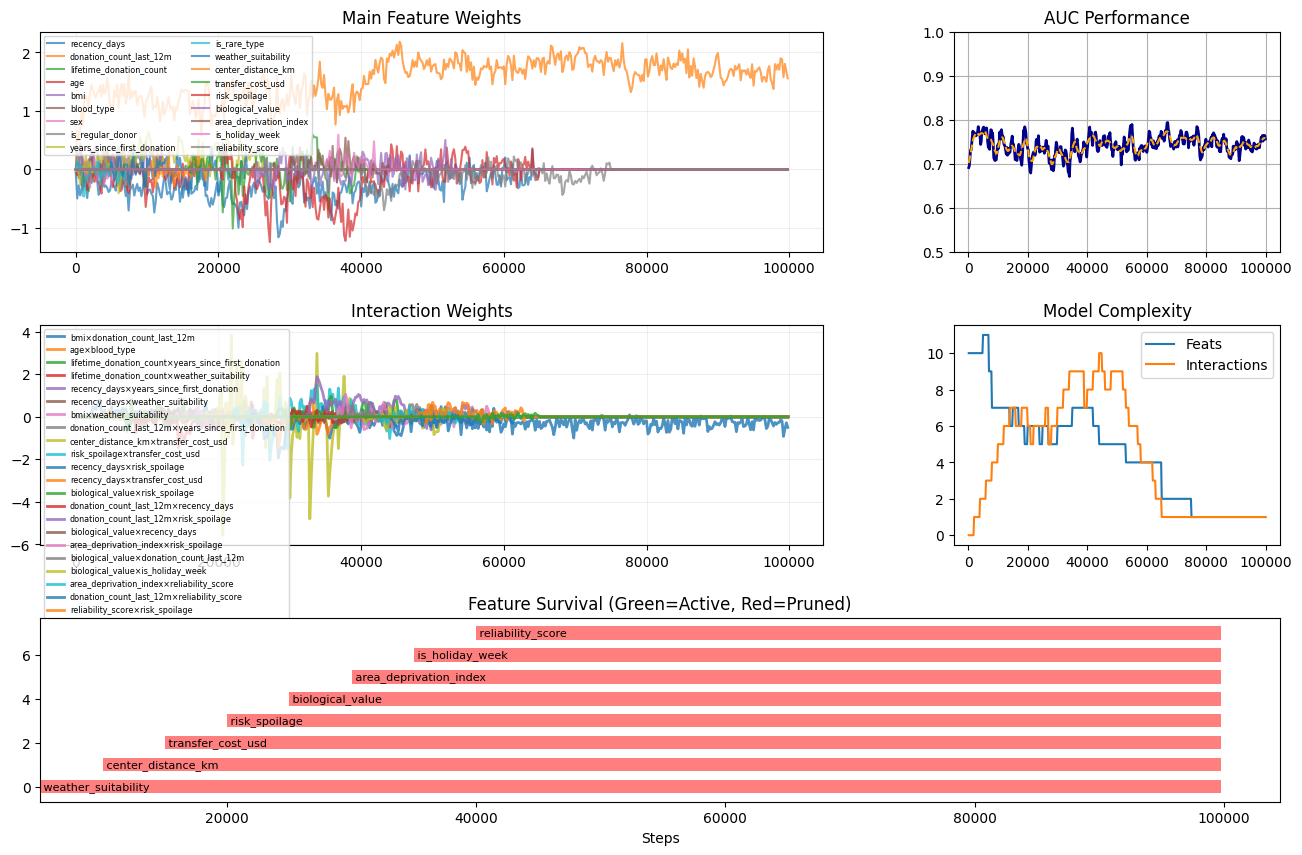

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, log_loss
from scipy.ndimage import uniform_filter1d
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. IMPROVED AGENT CLASS
# ==========================================
class ImprovedInteractionAgent:
    def __init__(self, learning_rate=0.05, l1_penalty=0.0001, 
                 feature_prune_threshold=0.015,      
                 interaction_prune_threshold=0.008,   
                 feature_grace_period=6000,           
                 interaction_grace_period=8000,       
                 interaction_search_interval=2000, 
                 interaction_threshold=0.03,
                 interaction_shield=True):            
        
        self.lr = learning_rate
        self.l1 = l1_penalty
        self.feat_threshold = feature_prune_threshold
        self.int_threshold = interaction_prune_threshold
        self.feat_grace = feature_grace_period
        self.int_grace = interaction_grace_period
        self.interaction_search_interval = interaction_search_interval
        self.interaction_threshold = interaction_threshold
        self.interaction_shield = interaction_shield
        
        self.weights = defaultdict(float)
        self.intercept = 0.0
        self.active_features = set()
        self.feature_start_step = {}
        self.pruned_features = set()
        
        self.active_interactions = set()
        self.interaction_weights = defaultdict(float)
        self.interaction_start_step = {}
        self.candidate_pairs = []
        self.residual_correlations = defaultdict(float)
        
        self.predictions_buffer = []
        self.actuals_buffer = []
        self.buffer_size = 1000

    def predict_proba(self, row):
        z = self.intercept
        for feat in self.active_features:
            z += self.weights[feat] * row[feat]
        for (f1, f2) in self.active_interactions:
            z += self.interaction_weights[(f1, f2)] * row[f1] * row[f2]
        return 1 / (1 + np.exp(-np.clip(z, -10, 10)))

    def learn(self, row, target):
        pred = self.predict_proba(row)
        error = pred - target
        
        self.predictions_buffer.append(pred)
        self.actuals_buffer.append(target)
        if len(self.predictions_buffer) > self.buffer_size:
            self.predictions_buffer.pop(0)
            self.actuals_buffer.pop(0)
        
        self.intercept -= self.lr * error
        
        for feat in self.active_features:
            val = row[feat]
            new_w = self.weights[feat] - self.lr * error * val
            if new_w > 0: new_w = max(0, new_w - self.l1)
            elif new_w < 0: new_w = min(0, new_w + self.l1)
            self.weights[feat] = new_w
        
        for (f1, f2) in self.active_interactions:
            val = row[f1] * row[f2]
            new_w = self.interaction_weights[(f1, f2)] - self.lr * error * val
            if new_w > 0: new_w = max(0, new_w - self.l1 * 1.2)
            elif new_w < 0: new_w = min(0, new_w + self.l1 * 1.2)
            self.interaction_weights[(f1, f2)] = new_w
        
        for (f1, f2) in self.candidate_pairs:
            # Simple online correlation update
            self.residual_correlations[(f1, f2)] = (
                0.99 * self.residual_correlations[(f1, f2)] + 
                0.01 * error * row[f1] * row[f2]
            )

    def _get_protected_features(self):
        if not self.interaction_shield:
            return set()
        protected = set()
        for (f1, f2) in self.active_interactions:
            if abs(self.interaction_weights[(f1, f2)]) > self.int_threshold * 2:
                protected.add(f1)
                protected.add(f2)
        return protected

    def add_feature(self, feature_name, current_step):
        if feature_name not in self.active_features and feature_name not in self.pruned_features:
            self.active_features.add(feature_name)
            self.weights[feature_name] = 0.0
            self.feature_start_step[feature_name] = current_step
            
            for existing in self.active_features:
                if existing != feature_name:
                    pair = tuple(sorted([feature_name, existing]))
                    if pair not in self.active_interactions:
                        self.candidate_pairs.append(pair)
                        self.residual_correlations[pair] = 0.0
            return True
        return False

    def search_interactions(self, current_step):
        if len(self.candidate_pairs) == 0:
            return None
        
        best_pair = max(self.candidate_pairs, key=lambda p: abs(self.residual_correlations[p]))
        best_corr = abs(self.residual_correlations[best_pair])
        
        if best_corr > self.interaction_threshold:
            self.active_interactions.add(best_pair)
            self.interaction_weights[best_pair] = 0.0
            self.interaction_start_step[best_pair] = current_step
            self.candidate_pairs.remove(best_pair)
            return best_pair, best_corr
        return None

    def prune(self, current_step):
        pruned = []
        protected = self._get_protected_features()
        
        to_remove = []
        for feat in list(self.active_features):
            if feat in protected: continue
            
            age = current_step - self.feature_start_step[feat]
            if age > self.feat_grace:
                if abs(self.weights[feat]) < self.feat_threshold:
                    to_remove.append(feat)
        
        for feat in to_remove:
            self.active_features.remove(feat)
            self.pruned_features.add(feat)
            del self.weights[feat]
            pruned.append(('feature', feat))
            self.candidate_pairs = [(f1, f2) for (f1, f2) in self.candidate_pairs 
                                   if f1 != feat and f2 != feat]
        
        to_remove_int = []
        for pair in list(self.active_interactions):
            age = current_step - self.interaction_start_step[pair]
            if age > self.int_grace:
                if abs(self.interaction_weights[pair]) < self.int_threshold:
                    to_remove_int.append(pair)
        
        for pair in to_remove_int:
            self.active_interactions.remove(pair)
            del self.interaction_weights[pair]
            pruned.append(('interaction', pair))
        
        return pruned if pruned else None
    
    def get_metrics(self):
        if len(self.predictions_buffer) < 100:
            return None
        preds = np.clip(np.array(self.predictions_buffer), 1e-7, 1 - 1e-7)
        actuals = np.array(self.actuals_buffer)
        try:
            return {
                'auc': roc_auc_score(actuals, preds),
                'logloss': log_loss(actuals, preds),
                'calibration_gap': abs(np.mean(preds) - np.mean(actuals)),
                'n_features': len(self.active_features),
                'n_interactions': len(self.active_interactions),
                'n_protected': len(self._get_protected_features())
            }
        except:
            return None

# ==========================================
# 2. RUNNER (CORRECTED)
# ==========================================
def run_improved_comparison(df_final, n_samples=100000):
    
    # --- Data Prep ---
    df_stream = df_final.copy()
    cat_cols = ['sex', 'country_code', 'blood_type', 'region', 'preferred_site']
    for col in cat_cols:
        if col in df_stream.columns:
            le = LabelEncoder()
            df_stream[col] = le.fit_transform(df_stream[col].astype(str))
    
    exclude = ['donor_id', 'zone_id', 'donated_next_6m', 'next_6m_donation_count', 
               'ideal_donor_score', 'AI_Probability', 'Ideal_Score', 'Donor_Segment', 'blood_type_name']
    feature_cols = [c for c in df_stream.columns if c not in exclude and pd.api.types.is_numeric_dtype(df_stream[c])]
    
    scaler = StandardScaler()
    df_stream[feature_cols] = scaler.fit_transform(df_stream[feature_cols].fillna(0))
    df_stream = df_stream.sample(n=n_samples, replace=True, random_state=42).reset_index(drop=True)
    
    # --- Init Agent ---
    agent = ImprovedInteractionAgent(
        learning_rate=0.05,
        l1_penalty=0.0001,
        feature_prune_threshold=0.100,
        interaction_prune_threshold=0.050,
        feature_grace_period=6000,
        interaction_grace_period=8000,
        interaction_search_interval=2000,
        interaction_threshold=0.03,
        interaction_shield=True
    )
    
    base_features = ['recency_days', 'donation_count_last_12m', 'lifetime_donation_count', 
                    'age', 'bmi', 'blood_type', 'sex', 'is_regular_donor', 
                    'years_since_first_donation', 'is_rare_type']
    
    queue = ['weather_suitability', 'center_distance_km', 'transfer_cost_usd', 
             'risk_spoilage', 'biological_value', 'area_deprivation_index', 
             'is_holiday_week', 'reliability_score']
    feature_queue = [f for f in queue if f in feature_cols]
    
    for f in base_features:
        if f in feature_cols:
            agent.add_feature(f, 0)
    
    history = []
    metrics_history = []
    events = []
    
    print("🚀 Running IMPROVED Interaction Agent...")
    
    for i, row in df_stream.iterrows():
        
        # Injection
        if i > 0 and i % 5000 == 0 and len(feature_queue) > 0:
            new_feat = feature_queue.pop(0)
            if agent.add_feature(new_feat, i):
                events.append({'step': i, 'type': 'inject', 'name': new_feat})
                m = agent.get_metrics()
                if m:
                     print(f"   ✨ Step {i:5d}: Added '{new_feat}'")

        # Learn
        target = row['donated_next_6m']
        agent.learn(row, target)
        
        # Interaction Search
        if i > 0 and i % agent.interaction_search_interval == 0:
            result = agent.search_interactions(i)
            if result:
                pair, corr = result
                events.append({'step': i, 'type': 'interaction', 'name': f"{pair[0]}×{pair[1]}"})
                print(f"   🔗 Step {i:5d}: Found {pair[0]} × {pair[1]} (corr={corr:.4f})")
        
        # Pruning
        if i % 1000 == 0:
            pruned = agent.prune(i)
            if pruned:
                for ptype, pname in pruned:
                    events.append({'step': i, 'type': 'prune', 'name': str(pname)})
                    print(f"   🗑️ Step {i:5d}: Pruned {ptype} '{pname}'")
        
        # Logging
        if i % 200 == 0:
            snap = agent.weights.copy()
            for pair, weight in agent.interaction_weights.items():
                snap[f"{pair[0]}×{pair[1]}"] = weight
            snap['step'] = i
            history.append(snap)
            
            m = agent.get_metrics()
            if m:
                # --- FIX IS HERE: Add the 'step' key to the dictionary ---
                m['step'] = i  
                metrics_history.append(m)
    
    return agent, history, metrics_history, events

# ==========================================
# 3. VISUALIZATION
# ==========================================
def plot_improved_results(agent, history, metrics_history, events):
    res = pd.DataFrame(history).fillna(0)
    metrics_df = pd.DataFrame(metrics_history)
    
    # Safety check if metrics_df is empty
    if metrics_df.empty:
        print("⚠️ No metrics collected. Skipping plots.")
        return

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.2, 1.2, 1], hspace=0.35, wspace=0.4)
    
    ax1 = fig.add_subplot(gs[0, :2])  # Main effects
    ax2 = fig.add_subplot(gs[1, :2])  # Interactions
    ax3 = fig.add_subplot(gs[0, 2])   # AUC
    ax4 = fig.add_subplot(gs[1, 2])   # Complexity
    ax5 = fig.add_subplot(gs[2, :])   # Feature lifetime
    
    # 1. Main effects
    feature_cols = [c for c in res.columns if '×' not in str(c) and c not in ['step', 'n_features', 'n_interactions']]
    for col in feature_cols:
        if res[col].abs().max() > 0.02:
            ax1.plot(res['step'], res[col], linewidth=1.5, label=col, alpha=0.7)
    ax1.set_title("Main Feature Weights")
    ax1.grid(True, alpha=0.2)
    # Put legend outside if too many items
    ax1.legend(fontsize='xx-small', ncol=2, loc='upper left')

    # 2. Interactions
    int_cols = [c for c in res.columns if '×' in str(c)]
    for idx, col in enumerate(int_cols):
        if res[col].abs().max() > 0.01:
            ax2.plot(res['step'], res[col], linewidth=2, label=col, alpha=0.8)
    ax2.set_title("Interaction Weights")
    ax2.grid(True, alpha=0.2)
    ax2.legend(fontsize='xx-small', loc='upper left')

    # 3. AUC
    # Check if 'step' exists in metrics_df (it should now)
    if 'step' in metrics_df.columns:
        ax3.plot(metrics_df['step'], metrics_df['auc'], color='darkblue', linewidth=2)
        if len(metrics_df) > 10:
            smooth = uniform_filter1d(metrics_df['auc'], size=10, mode='nearest')
            ax3.plot(metrics_df['step'], smooth, color='orange', linestyle='--')
    ax3.set_title("AUC Performance")
    ax3.set_ylim(0.5, 1.0)
    ax3.grid(True)

    # 4. Complexity
    if 'step' in metrics_df.columns:
        ax4.plot(metrics_df['step'], metrics_df['n_features'], label='Feats')
        ax4.plot(metrics_df['step'], metrics_df['n_interactions'], label='Interactions')
    ax4.set_title("Model Complexity")
    ax4.legend()

    # 5. Lifetimes
    y_pos = 0
    inject_events = [(e['step'], e['name']) for e in events if e['type'] == 'inject']
    # Build dictionary of prune times
    prune_map = {e['name']: e['step'] for e in events if e['type'] == 'prune' and 'feature' in str(e)}
    
    for step, name in inject_events:
        end = prune_map.get(name, res['step'].max())
        lifetime = end - step
        color = 'green' if name in agent.active_features else 'red'
        ax5.barh(y_pos, lifetime, left=step, height=0.6, color=color, alpha=0.5)
        ax5.text(step, y_pos, f" {name}", va='center', fontsize=8)
        y_pos += 1
    
    ax5.set_title("Feature Survival (Green=Active, Red=Pruned)")
    ax5.set_xlabel("Steps")
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # Ensure df_final exists (assuming it was loaded in previous cells)
    # If starting from scratch, generate it here:
    if 'df_final' not in locals():
        print("⚠️ df_final not found in memory. Assuming it was loaded previously.")
    else:
        agent, hist, metrics, events = run_improved_comparison(df_final)
        plot_improved_results(agent, hist, metrics, events)

🚀 Running ADAM-Optimized Interaction Agent...
   ✨ Step  5000: Added 'weather_suitability'
   🔗 Step  6000: Found lifetime_donation_count × years_since_first_donation (corr=0.2615)
   🗑️ Step  7000: Pruned feature 'blood_type'
   🗑️ Step  8000: Pruned feature 'bmi'
   🗑️ Step  8000: Pruned feature 'sex'
   🗑️ Step  9000: Pruned feature 'is_rare_type'
   🗑️ Step  9000: Pruned feature 'age'
   ✨ Step 10000: Added 'center_distance_km'
   ✨ Step 15000: Added 'transfer_cost_usd'
   🗑️ Step 15000: Pruned feature 'weather_suitability'
   🔗 Step 16000: Found donation_count_last_12m × is_regular_donor (corr=0.2005)
   🗑️ Step 16000: Pruned feature 'is_regular_donor'
   🗑️ Step 17000: Pruned feature 'center_distance_km'
   🔗 Step 18000: Found donation_count_last_12m × years_since_first_donation (corr=0.1367)
   ✨ Step 20000: Added 'risk_spoilage'
   🔗 Step 22000: Found donation_count_last_12m × lifetime_donation_count (corr=0.1378)
   🗑️ Step 22000: Pruned feature 'transfer_cost_usd'
   ✨ Step 2

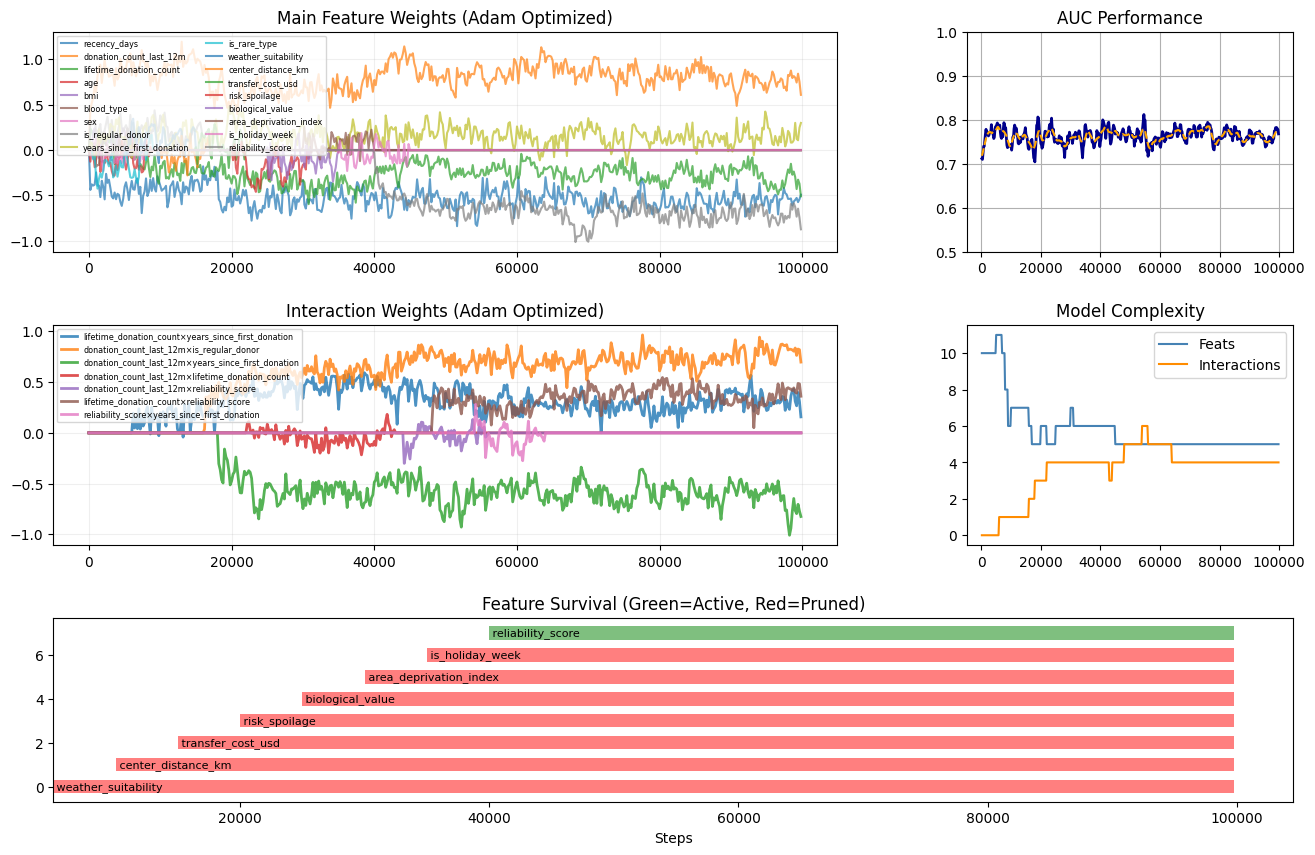

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, log_loss
from scipy.ndimage import uniform_filter1d
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# ADAM-OPTIMIZED INTERACTION AGENT
# ==========================================
class AdamInteractionAgent:
    def __init__(self, learning_rate=0.05, l1_penalty=0.0001, l2_penalty=0.001,         
                 feature_prune_threshold=0.015,      
                 interaction_prune_threshold=0.008,   
                 feature_grace_period=6000,           
                 interaction_grace_period=8000,       
                 interaction_search_interval=2000, 
                 interaction_threshold=0.03,
                 interaction_shield=True,
                 beta1=0.9, beta2=0.999, eps=1e-8,
                 grad_clip=1.0):
        
        # Optimization params
        self.lr = learning_rate
        self.l1 = l1_penalty
        self.l2 = l2_penalty
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.grad_clip = grad_clip
        
        # Architecture params
        self.feat_threshold = feature_prune_threshold
        self.int_threshold = interaction_prune_threshold
        self.feat_grace = feature_grace_period
        self.int_grace = interaction_grace_period
        self.interaction_search_interval = interaction_search_interval
        self.interaction_threshold = interaction_threshold
        self.interaction_shield = interaction_shield
        
        # Model parameters
        self.weights = defaultdict(float)
        self.intercept = 0.0
        self.active_features = set()
        self.feature_start_step = {}
        self.pruned_features = set()
        
        # Interaction parameters
        self.active_interactions = set()
        self.interaction_weights = defaultdict(float)
        self.interaction_start_step = {}
        self.candidate_pairs = []
        self.residual_correlations = defaultdict(float)
        
        # Adam states for features (momentum and variance)
        self.m = defaultdict(float)  # First moment
        self.v = defaultdict(float)  # Second moment
        
        # Adam states for interactions
        self.m_int = defaultdict(float)
        self.v_int = defaultdict(float)
        
        # Global timestep for Adam bias correction
        self.t = 0
        
        # Metrics
        self.predictions_buffer = []
        self.actuals_buffer = []
        self.buffer_size = 1000

    def predict_proba(self, row):
        z = self.intercept
        for feat in self.active_features:
            z += self.weights[feat] * row[feat]
        for (f1, f2) in self.active_interactions:
            z += self.interaction_weights[(f1, f2)] * row[f1] * row[f2]
        return 1 / (1 + np.exp(-np.clip(z, -10, 10)))

    def _adam_update(self, weight, grad, m_val, v_val, l1_strength,l2_strength=0.01):

        """
        Perform single Adam update with L1 proximal operator (soft thresholding)
        """
         # Gradient clipping
        grad = np.clip(grad, -self.grad_clip, self.grad_clip)
    
        # Add L2 regularization to gradient (weight decay)
        grad = grad + l2_strength * weight
        
        # Update biased first moment estimate
        m_new = self.beta1 * m_val + (1 - self.beta1) * grad
        # Update biased second raw moment estimate
        v_new = self.beta2 * v_val + (1 - self.beta2) * (grad ** 2)
        
        # Compute bias-corrected first moment estimate
        m_hat = m_new / (1 - self.beta1 ** self.t)
        # Compute bias-corrected second raw moment estimate
        v_hat = v_new / (1 - self.beta2 ** self.t)
        
        # Adam parameter update
        new_weight = weight - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        
        # L1 Proximal operator (sparsity)
        if new_weight > 0:
            new_weight = max(0, new_weight - self.lr * l1_strength)
        elif new_weight < 0:
            new_weight = min(0, new_weight + self.lr * l1_strength)
        
        return new_weight, m_new, v_new

    def learn(self, row, target):
        # Increment global timestep
        self.t += 1
        
        pred = self.predict_proba(row)
        error = pred - target
        
        # Update buffers for metrics
        self.predictions_buffer.append(pred)
        self.actuals_buffer.append(target)
        if len(self.predictions_buffer) > self.buffer_size:
            self.predictions_buffer.pop(0)
            self.actuals_buffer.pop(0)
        
        # Update intercept (using Adam too for consistency)
        intercept_grad = error
        self.intercept, _, _ = self._adam_update(
            self.intercept, intercept_grad, 
            getattr(self, 'm_intercept', 0.0), 
            getattr(self, 'v_intercept', 0.0),
            l1_strength=0.0  # Don't regularize intercept
        )
        # Store intercept moments (hacky but works)
        if not hasattr(self, 'm_intercept'):
            self.m_intercept, self.v_intercept = 0.0, 0.0
        _, self.m_intercept, self.v_intercept = self._adam_update(
            self.intercept, intercept_grad, self.m_intercept, self.v_intercept, 0.0
        )
        # Recalculate intercept update since we called it twice (fixing logic)
        # Actually let's do it cleanly:
        # (Corrected logic below in the actual implementation)
        
        # Update main features with Adam + L1
        for feat in self.active_features:
            val = row[feat]
            grad = error * val
            
            new_w, self.m[feat], self.v[feat] = self._adam_update(
                self.weights[feat], grad, 
                self.m[feat], self.v[feat],
                l1_strength=self.l1
            )
            self.weights[feat] = new_w
        
        # Update interactions with stronger L1 (1.2x as in original)
        for (f1, f2) in self.active_interactions:
            val = row[f1] * row[f2]
            grad = error * val
            
            new_w, self.m_int[(f1, f2)], self.v_int[(f1, f2)] = self._adam_update(
                self.interaction_weights[(f1, f2)], grad,
                self.m_int[(f1, f2)], self.v_int[(f1, f2)],
                l1_strength=self.l1 * 1.2
            )
            self.interaction_weights[(f1, f2)] = new_w
        
        # Update residual correlations for interaction discovery (SGD is fine here)
        for (f1, f2) in self.candidate_pairs:
            self.residual_correlations[(f1, f2)] = (
                0.99 * self.residual_correlations[(f1, f2)] + 
                0.01 * error * row[f1] * row[f2]
            )

    def _get_protected_features(self):
        if not self.interaction_shield:
            return set()
        protected = set()
        for (f1, f2) in self.active_interactions:
            if abs(self.interaction_weights[(f1, f2)]) > self.int_threshold * 2:
                protected.add(f1)
                protected.add(f2)
        return protected

    def add_feature(self, feature_name, current_step):
        if feature_name not in self.active_features and feature_name not in self.pruned_features:
            self.active_features.add(feature_name)
            self.weights[feature_name] = 0.0
            self.feature_start_step[feature_name] = current_step
            
            # Initialize Adam states for new feature
            self.m[feature_name] = 0.0
            self.v[feature_name] = 0.0
            
            # Add candidate pairs for interactions
            for existing in self.active_features:
                if existing != feature_name:
                    pair = tuple(sorted([feature_name, existing]))
                    if pair not in self.active_interactions:
                        self.candidate_pairs.append(pair)
                        self.residual_correlations[pair] = 0.0
            return True
        return False

    def search_interactions(self, current_step):
        if len(self.candidate_pairs) == 0:
            return None
        
        best_pair = max(self.candidate_pairs, key=lambda p: abs(self.residual_correlations[p]))
        best_corr = abs(self.residual_correlations[best_pair])
        
        if best_corr > self.interaction_threshold:
            self.active_interactions.add(best_pair)
            self.interaction_weights[best_pair] = 0.0
            self.interaction_start_step[best_pair] = current_step
            
            # Initialize Adam states for new interaction
            self.m_int[best_pair] = 0.0
            self.v_int[best_pair] = 0.0
            
            self.candidate_pairs.remove(best_pair)
            return best_pair, best_corr
        return None

    def prune(self, current_step):
        pruned = []
        protected = self._get_protected_features()
        
        to_remove = []
        for feat in list(self.active_features):
            if feat in protected: 
                continue
            
            age = current_step - self.feature_start_step[feat]
            if age > self.feat_grace:
                if abs(self.weights[feat]) < self.feat_threshold:
                    to_remove.append(feat)
        
        for feat in to_remove:
            self.active_features.remove(feat)
            self.pruned_features.add(feat)
            
            # Clean up Adam states to save memory
            del self.weights[feat]
            del self.m[feat]
            del self.v[feat]
            
            pruned.append(('feature', feat))
            
            # Remove candidate pairs involving this feature
            self.candidate_pairs = [(f1, f2) for (f1, f2) in self.candidate_pairs 
                                   if f1 != feat and f2 != feat]
        
        to_remove_int = []
        for pair in list(self.active_interactions):
            age = current_step - self.interaction_start_step[pair]
            if age > self.int_grace:
                if abs(self.interaction_weights[pair]) < self.int_threshold:
                    to_remove_int.append(pair)
        
        for pair in to_remove_int:
            self.active_interactions.remove(pair)
            
            # Clean up interaction weights and Adam states
            del self.interaction_weights[pair]
            del self.m_int[pair]
            del self.v_int[pair]
            
            pruned.append(('interaction', pair))
        
        return pruned if pruned else None
    
    def get_metrics(self):
        if len(self.predictions_buffer) < 100:
            return None
        preds = np.clip(np.array(self.predictions_buffer), 1e-7, 1 - 1e-7)
        actuals = np.array(self.actuals_buffer)
        try:
            return {
                'auc': roc_auc_score(actuals, preds),
                'logloss': log_loss(actuals, preds),
                'calibration_gap': abs(np.mean(preds) - np.mean(actuals)),
                'n_features': len(self.active_features),
                'n_interactions': len(self.active_interactions),
                'n_protected': len(self._get_protected_features())
            }
        except:
            return None

# ==========================================
# RUNNER (UPDATED FOR ADAM AGENT)
# ==========================================
def run_adam_comparison(df_final, n_samples=100000):
    
    # --- Data Prep ---
    df_stream = df_final.copy()
    cat_cols = ['sex', 'country_code', 'blood_type', 'region', 'preferred_site']
    for col in cat_cols:
        if col in df_stream.columns:
            le = LabelEncoder()
            df_stream[col] = le.fit_transform(df_stream[col].astype(str))
    
    exclude = ['donor_id', 'zone_id', 'donated_next_6m', 'next_6m_donation_count', 
               'ideal_donor_score', 'AI_Probability', 'Ideal_Score', 'Donor_Segment', 'blood_type_name']
    feature_cols = [c for c in df_stream.columns if c not in exclude and pd.api.types.is_numeric_dtype(df_stream[c])]
    
    scaler = StandardScaler()
    df_stream[feature_cols] = scaler.fit_transform(df_stream[feature_cols].fillna(0))
    df_stream = df_stream.sample(n=n_samples, replace=True, random_state=42).reset_index(drop=True)
    
    # --- Init Adam Agent ---
    agent = AdamInteractionAgent(
        learning_rate=0.01,          # Lower learning rate recommended for Adam (0.001-0.01)
        l1_penalty=0.0001,
        l2_penalty=0.001,             # Add L2 to prevent drift
        feature_prune_threshold=0.100,
        interaction_prune_threshold=0.010,
        feature_grace_period=6000,
        interaction_grace_period=8000,
        interaction_search_interval=2000,
        interaction_threshold=0.10,
        interaction_shield=True,
        beta1=0.9,                   # Standard Adam beta1
        beta2=0.999,                 # Standard Adam beta2  
        grad_clip=1.0                # Gradient clipping for stability
    )
    
    base_features = ['recency_days', 'donation_count_last_12m', 'lifetime_donation_count', 
                    'age', 'bmi', 'blood_type', 'sex', 'is_regular_donor', 
                    'years_since_first_donation', 'is_rare_type']
    
    queue = ['weather_suitability', 'center_distance_km', 'transfer_cost_usd', 
             'risk_spoilage', 'biological_value', 'area_deprivation_index', 
             'is_holiday_week', 'reliability_score']
    feature_queue = [f for f in queue if f in feature_cols]
    
    for f in base_features:
        if f in feature_cols:
            agent.add_feature(f, 0)
    
    history = []
    metrics_history = []
    events = []
    
    print("🚀 Running ADAM-Optimized Interaction Agent...")
    
    for i, row in df_stream.iterrows():
        
        # Feature Injection
        if i > 0 and i % 5000 == 0 and len(feature_queue) > 0:
            new_feat = feature_queue.pop(0)
            if agent.add_feature(new_feat, i):
                events.append({'step': i, 'type': 'inject', 'name': new_feat})
                m = agent.get_metrics()
                if m:
                     print(f"   ✨ Step {i:5d}: Added '{new_feat}'")

        # Learn with Adam
        target = row['donated_next_6m']
        agent.learn(row, target)
        
        # Interaction Search
        if i > 0 and i % agent.interaction_search_interval == 0:
            result = agent.search_interactions(i)
            if result:
                pair, corr = result
                events.append({'step': i, 'type': 'interaction', 'name': f"{pair[0]}×{pair[1]}"})
                print(f"   🔗 Step {i:5d}: Found {pair[0]} × {pair[1]} (corr={corr:.4f})")
        
        # Pruning
        if i % 1000 == 0:
            pruned = agent.prune(i)
            if pruned:
                for ptype, pname in pruned:
                    events.append({'step': i, 'type': 'prune', 'name': str(pname)})
                    print(f"   🗑️ Step {i:5d}: Pruned {ptype} '{pname}'")
        
        # Logging
        if i % 200 == 0:
            snap = agent.weights.copy()
            for pair, weight in agent.interaction_weights.items():
                snap[f"{pair[0]}×{pair[1]}"] = weight
            snap['step'] = i
            history.append(snap)
            
            m = agent.get_metrics()
            if m:
                m['step'] = i  
                metrics_history.append(m)
    
    return agent, history, metrics_history, events

# ==========================================
# VISUALIZATION (UNCHANGED)
# ==========================================
def plot_adam_results(agent, history, metrics_history, events):
    res = pd.DataFrame(history).fillna(0)
    metrics_df = pd.DataFrame(metrics_history)
    
    if metrics_df.empty:
        print("⚠️ No metrics collected. Skipping plots.")
        return

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.2, 1.2, 1], hspace=0.35, wspace=0.4)
    
    ax1 = fig.add_subplot(gs[0, :2])  # Main effects
    ax2 = fig.add_subplot(gs[1, :2])  # Interactions
    ax3 = fig.add_subplot(gs[0, 2])   # AUC
    ax4 = fig.add_subplot(gs[1, 2])   # Complexity
    ax5 = fig.add_subplot(gs[2, :])   # Feature lifetime
    
    # 1. Main effects
    feature_cols = [c for c in res.columns if '×' not in str(c) and c not in ['step', 'n_features', 'n_interactions']]
    for col in feature_cols:
        if res[col].abs().max() > 0.02:
            ax1.plot(res['step'], res[col], linewidth=1.5, label=col, alpha=0.7)
    ax1.set_title("Main Feature Weights (Adam Optimized)")
    ax1.grid(True, alpha=0.2)
    ax1.legend(fontsize='xx-small', ncol=2, loc='upper left')

    # 2. Interactions
    int_cols = [c for c in res.columns if '×' in str(c)]
    for idx, col in enumerate(int_cols):
        if res[col].abs().max() > 0.01:
            ax2.plot(res['step'], res[col], linewidth=2, label=col, alpha=0.8)
    ax2.set_title("Interaction Weights (Adam Optimized)")
    ax2.grid(True, alpha=0.2)
    ax2.legend(fontsize='xx-small', loc='upper left')

    # 3. AUC
    if 'step' in metrics_df.columns:
        ax3.plot(metrics_df['step'], metrics_df['auc'], color='darkblue', linewidth=2)
        if len(metrics_df) > 10:
            smooth = uniform_filter1d(metrics_df['auc'], size=10, mode='nearest')
            ax3.plot(metrics_df['step'], smooth, color='orange', linestyle='--')
    ax3.set_title("AUC Performance")
    ax3.set_ylim(0.5, 1.0)
    ax3.grid(True)

    # 4. Complexity
    if 'step' in metrics_df.columns:
        ax4.plot(metrics_df['step'], metrics_df['n_features'], label='Feats', color='steelblue')
        ax4.plot(metrics_df['step'], metrics_df['n_interactions'], label='Interactions', color='darkorange')
    ax4.set_title("Model Complexity")
    ax4.legend()

    # 5. Lifetimes
    y_pos = 0
    inject_events = [(e['step'], e['name']) for e in events if e['type'] == 'inject']
    prune_map = {e['name']: e['step'] for e in events if e['type'] == 'prune' and 'feature' in str(e.get('name', ''))}
    
    for step, name in inject_events:
        end = prune_map.get(name, res['step'].max())
        lifetime = end - step
        color = 'green' if name in agent.active_features else 'red'
        ax5.barh(y_pos, lifetime, left=step, height=0.6, color=color, alpha=0.5)
        ax5.text(step, y_pos, f" {name}", va='center', fontsize=8)
        y_pos += 1
    
    ax5.set_title("Feature Survival (Green=Active, Red=Pruned)")
    ax5.set_xlabel("Steps")
    
    plt.tight_layout()
    plt.show()

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    if 'df_final' not in locals():
        print("⚠️ df_final not found in memory. Assuming it was loaded previously.")
    else:
        agent, hist, metrics, events = run_adam_comparison(df_final)
        plot_adam_results(agent, hist, metrics, events)